# **CAPSTONE PROJECT**


Submitted by: Leslie Anne D. Dolot

Date of Submission: 30 March 2026


In [ ]:
# IMPORT LIBRARIES
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

def ensure_package(pkg_name, import_name=None):
    """Install package if import fails."""
    import importlib
    try:
        importlib.import_module(import_name or pkg_name)
    except Exception:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])
        except Exception as e:
            print(f'Package install skipped/failed for {pkg_name}: {e}')

for pkg, imp in [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
    ('seaborn', 'seaborn'),
    ('xgboost', 'xgboost'),
    ('shap', 'shap'),
]:
    ensure_package(pkg, imp)

import os
import re
import json
import math
import textwrap
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')
np.random.seed(42)
random.seed(42)

**STEP 1: PROBLEM FRAMING**

Problem Statement:

Food Panda management is reviewing their August 2024-2025 data on the orders made in their platform and they noticed a relatively high number of cancelled delivery status (>30%).
High cancellation rates in a delivery business is a serious signal that something is breaking in the ecosystem (customers, riders, or restaurants). The impact of this includes direct revenue loss as every order cancelled is a lost transaction. This would mean no commission from restaurants, no delivery fee collected and there are wasted promos/discount. There are also higher operating cost as cancelled orders still incur costs on the rider’s time and fuel which are wasted, there is also the customer support handling complaints/refunds, and the cost on payment processing reversals. This also signals poor customer experience as cancellations could come from customers’ frustrations due to either longer wait times with no food delivered, the uncertainty if the delivery will come on time, and/ or fund delays. The customers may then switch to competitors like GrabFood and others. Other than this, the restaurant partners are also affected as cancellation may result to wasted food preparation (if already cooked), operational inefficiency, and the lowering of trust in the platform. The riders are also impacted as they lose earnings from cancelled trips, the increase in idle time and inefficiencies, and cancellations could also lead to lowering of their morale. If unaddressed, this may lead to lower rider retention or poorer service quality. Order cancellation also damages brand trust as customers will find the platform unreliable as there is lower repeat usage, negative word-of-mouth, and lower app rating. If Food Panda is also employing data forecasting (which they should be), high cancellations could distort the data and skew demand forecasting. It may lead to misleading supply allocations and affect performance metrics. This can then lead to poorer decision-making.

Given these above-mentioned effects and impact of high order cancellation, below is the problem statement:
“Which orders are likely to be cancelled before fulfillment?”

MAIN OBJECTIVE:

By being able to predict which orders are likely to be cancelled, we can reduce the number of order cancellations in a year and avoid or reduce the negative impacts of cancelled orders.

Once the management is able to identify this, they could trigger proactive interventions (discounts, faster dispatch, alerts), provide changes, solutions and remedies before it results in a huge negative impact in the whole business financials.



MACHINE LEARNING TASK TYPE:

Classification

SUCCESS METRICS:

The technical success metrics that will be used here are the following:

1. Recall

This is the measurement of % actual cancellations correctly identified. A high recall would mean fewer missed risky orders. This is very important because our goal is to catch as many correct cancelled orders and reduce the "missed" cancellations due to poor predictions in order to bring down the number of actual cancellations.

2. F1 Score

This will provide balance on precision and recall information.


3. Precision

This will measure % predicted cancellations that are actually cancelled. This would help the management correctly identify where interventions are truly needed such that the management will not waste money due to interventions done (discounts, prioritizations, etc.).

4. ROC-AUC and PR-AUC

This will measure the ability to distinguish cancelled vs non-cancelled orders. We will also be able to rank orders by risks, and we can prioritize top-risk orders for intervention.


The business success matrix or KPIs are the following:

1. High prediction of potentially cancelled orders or Prevented Cancellations

Formula:
Prevented Cancellations = total orders saved due to intervention

Objective:
Reduce the number of cancelled orders in the same time frame as the previous data.

2. Cancellation Rate Reduction

Formula:
(New Cancellation Rate - Old Rate) / Old Rate

Objective:
Lower overall cancellations

3. C.	Revenue Retained

Formula:
Revenue Retained = ∑(value of orders where cancellation is prevented)

Objective:
The higher the value, then more revenue is generated.

4. Intervention Cost vs Savings

Formula:
Net Benefit = Revenue Retained - Cost of Intervention

Objective:
The Net Benefit must be a positive value.

5. Precision at Top 10% highest-risks orders

Objective:
Identify what are the top 10 high-risk orders so that the management will only act on these, to also save money on interventions.


TARGET VARIABLE:

*"Cancelled" delivery status*

**STEP 2: DATA LOADING & INITIAL EXPLORATION**

Dataset was obtained from KAGGLE and the link can be accessed in the link below.

Data Source:
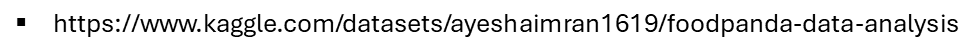



In [ ]:
# UPLOADING CSV FILE
import pandas as pd
file_name = 'Foodpanda Analysis Dataset.csv'
print('\n' + '='*80)
print('STEP 2: UPLOAD CSV FILE')
print('='*80)
df = pd.read_csv(file_name)
print(f'Loaded file: {file_name}')
print(f'Dataset shape: {df.shape}')
display(df.head())


STEP 2: UPLOAD CSV FILE
Loaded file: Foodpanda Analysis Dataset.csv
Dataset shape: (6000, 21)


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,...,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status,Unnamed: 20
0,C5221,Male,Senior,Lahore,10/3/2023,O9221,1/10/2024,McDonald's,Burger,Italian,...,1291.14,Card,7,8/21/2025,42,Inactive,3,11/29/2024,Cancelled,NaN
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,...,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed,NaN
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,...,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed,NaN
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,...,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed,NaN
4,C5641,Other,Senior,Islamabad,10/13/2023,O9641,3/27/2024,Pizza Hut,Burger,Chinese,...,620.96,Card,17,8/21/2025,206,Active,2,4/9/2025,Cancelled,NaN


In [ ]:
# Summarize feature types, missing values, outliers, etc.

import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

def ensure_package(pkg_name, import_name=None):
    """Install package if import fails."""
    import importlib
    try:
        importlib.import_module(import_name or pkg_name)
    except Exception:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])
        except Exception as e:
            print(f'Package install skipped/failed for {pkg_name}: {e}')

for pkg, imp in [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
    ('seaborn', 'seaborn'),
    ('xgboost', 'xgboost'),
    ('shap', 'shap'),
]:
    ensure_package(pkg, imp)

import os
import re
import json
import math
import textwrap
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')
np.random.seed(42)
random.seed(42)

def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return {
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_pct': (len(outliers) / len(series)) * 100 if len(series) > 0 else 0
    }

def safe_to_datetime(series):
    return pd.to_datetime(series, errors='coerce')

print('STEP 2: DATA QUALITY SUMMARY')

feature_summary = pd.DataFrame({
    'variable': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_pct': (df.isna().mean().values * 100).round(2),
    'n_unique': [df[c].nunique(dropna=True) for c in df.columns]
})
display(feature_summary)

numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_rows = []
for col in numeric_cols_raw:
    outlier_info = detect_outliers_iqr(df[col].dropna())
    outlier_info['variable'] = col
    outlier_rows.append(outlier_info)
outlier_df = pd.DataFrame(outlier_rows)[[
    'variable', 'q1', 'q3', 'iqr', 'lower_bound', 'upper_bound', 'outlier_count', 'outlier_pct'
]]
print('\nOutlier summary (IQR method):')
display(outlier_df)

# Date integrity checks
potential_date_cols = [c for c in df.columns if 'date' in c.lower()]
date_issue_log = []
for c in potential_date_cols:
    parsed = safe_to_datetime(df[c])
    date_issue_log.append({
        'date_column': c,
        'unparseable_dates': int(parsed.isna().sum()),
        'min_date': parsed.min(),
        'max_date': parsed.max()
    })
date_issue_df = pd.DataFrame(date_issue_log)
print('\nDate parsing summary:')
display(date_issue_df)

# Detect potentially problematic columns and data leakage
problematic_notes = []
all_nan_cols = [c for c in df.columns if df[c].isna().all()]
if all_nan_cols:
    problematic_notes.append(f"Columns with all missing values: {all_nan_cols} -> drop them.")

high_cardinality_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() > max(100, 0.2 * len(df))]
if high_cardinality_cols:
    problematic_notes.append(f"High-cardinality identifiers/text columns: {high_cardinality_cols} -> usually drop from modeling.")

# Specific chronology issues if the expected columns exist
for a, b, note in [
    ('signup_date', 'order_date', 'signup_date occurs after order_date'),
    ('last_order_date', 'order_date', 'last_order_date occurs after order_date'),
    ('rating_date', 'order_date', 'rating_date occurs before order_date')
]:
    if a in df.columns and b in df.columns:
        a_dt = safe_to_datetime(df[a])
        b_dt = safe_to_datetime(df[b])
        if note == 'signup_date occurs after order_date':
            count = int((a_dt > b_dt).sum())
        elif note == 'last_order_date occurs after order_date':
            count = int((a_dt > b_dt).sum())
        else:
            count = int((a_dt < b_dt).sum())
        problematic_notes.append(f"Chronology check: {note} in {count} rows.")

# Leakage notes
for leakage_col in ['rating', 'rating_date', 'churned']:
    if leakage_col in df.columns:
        problematic_notes.append(
            f"Potential target leakage: '{leakage_col}' may only be known after delivery/cancellation outcome -> drop for pre-fulfillment prediction."
        )

print('\nProblematic data findings and recommendations:')
for idx, note in enumerate(problematic_notes, start=1):
    print(f'{idx}. {note}')

print('\nRecommended cleaning actions implemented later in this script:')
print('1. Drop empty or useless columns such as unnamed/all-missing columns.')
print('2. Parse dates safely and create timing-based features known before fulfillment.')
print('3. Remove identifier columns from modeling (for example customer_id and order_id).')
print('4. Drop likely leakage columns only known after fulfillment (for example rating, rating_date, churned).')
print('5. Cap numeric outliers using the IQR method instead of deleting many rows.')

STEP 2: DATA QUALITY SUMMARY


,variable,dtype,missing_count,missing_pct,n_unique
0,customer_id,object,0,0.00,6000
1,gender,object,0,0.00,3
2,age,object,0,0.00,3
3,city,object,0,0.00,5
4,signup_date,object,0,0.00,730
5,order_id,object,0,0.00,6000
6,order_date,object,0,0.00,730
7,restaurant_name,object,0,0.00,5
8,dish_name,object,0,0.00,5
9,category,object,0,0.00,5



Outlier summary (IQR method):


,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,quantity,2.0000,4.0000,2.00,-1.0000,7.0000,0,0.0
1,price,441.9975,1149.7375,707.74,-619.6125,2211.3475,0,0.0
2,order_frequency,13.0000,37.0000,24.00,-23.0000,73.0000,0,0.0
3,loyalty_points,125.0000,378.0000,253.00,-254.5000,757.5000,0,0.0
4,rating,2.0000,4.0000,2.00,-1.0000,7.0000,0,0.0
5,Unnamed: 20,0.3280,0.3280,0.00,0.3280,0.3280,0,0.0



Date parsing summary:


,date_column,unparseable_dates,min_date,max_date
0,signup_date,0,2023-08-22,2025-08-21
1,order_date,0,2023-08-23,2025-08-22
2,last_order_date,0,2024-08-21,2025-08-21
3,rating_date,0,2024-08-21,2025-08-21



Problematic data findings and recommendations:
1. High-cardinality identifiers/text columns: ['customer_id', 'order_id'] -> usually drop from modeling.
2. Chronology check: signup_date occurs after order_date in 3028 rows.
3. Chronology check: last_order_date occurs after order_date in 4514 rows.
4. Chronology check: rating_date occurs before order_date in 1507 rows.
5. Potential target leakage: 'rating' may only be known after delivery/cancellation outcome -> drop for pre-fulfillment prediction.
6. Potential target leakage: 'rating_date' may only be known after delivery/cancellation outcome -> drop for pre-fulfillment prediction.
7. Potential target leakage: 'churned' may only be known after delivery/cancellation outcome -> drop for pre-fulfillment prediction.

Recommended cleaning actions implemented later in this script:
1. Drop empty or useless columns such as unnamed/all-missing columns.
2. Parse dates safely and create timing-based features known before fulfillment.
3. Remove id

*Columns removed as they are not necessary for the modelling and does not affect the cancelled orders:*
1. Identifier columns: "customer_id", "order_id".
2. Data leakages: "rating", "rating_date", and "churned". Rating is dropped because if an order is cancelled, the rating could either be none or very low. This may result to the model learning that low rating could yield to cancellation of orders and not the other way around.

In [ ]:
# STEP 2: DATA DICTIONARY

import pandas as pd

def infer_units_and_allowed_values(df, col):
    dtype = df[col].dtype
    unit = 'N/A'
    allowed_values = 'N/A'

    if pd.api.types.is_numeric_dtype(dtype):
        unit = 'Numeric'
        if col == 'price':
            unit = 'Currency (e.g., USD)'
        elif col == 'quantity':
            unit = 'Units'
        elif col == 'order_frequency':
            unit = 'Days'
        elif col == 'loyalty_points':
            unit = 'Points'
        elif col == 'rating':
            unit = 'Scale (1-5)'
        allowed_values = f"Min: {df[col].min()}, Max: {df[col].max()}"
    elif pd.api.types.is_datetime64_any_dtype(dtype) or 'date' in col.lower():
        unit = 'Date'
        # For date columns, display min and max dates
        min_date = pd.to_datetime(df[col], errors='coerce').min()
        max_date = pd.to_datetime(df[col], errors='coerce').max()
        allowed_values = f"Min Date: {min_date}, Max Date: {max_date}"
    elif pd.api.types.is_object_dtype(dtype):
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) <= 20: # If few unique values, list them
            unit = 'Categorical'
            allowed_values = ', '.join(map(str, unique_vals))
        else: # If many unique values, describe them generally
            unit = 'Text/High Cardinality'
            # Limit to first 5 examples if many unique values
            allowed_values = f"Too many unique values ({len(unique_vals)}) to list. Examples: {', '.join(map(str, unique_vals[:5]))}..."
            if col in ['customer_id', 'order_id']:
                unit = 'Identifier'

    return unit, allowed_values

print('STEP 2: DATA DICTIONARY')

data_dict_rows = []
for col in df.columns:
    unit, allowed = infer_units_and_allowed_values(df, col)
    data_dict_rows.append({
        'variable': col,
        'type': str(df[col].dtype),
        'unit': unit,
        'allowed_values': allowed
    })
data_dictionary = pd.DataFrame(data_dict_rows)
display(data_dictionary)

STEP 2: DATA DICTIONARY


,variable,type,unit,allowed_values
0,customer_id,object,Identifier,Too many unique values (6000) to list. Example...
1,gender,object,Categorical,"Male, Other, Female"
2,age,object,Categorical,"Senior, Adult, Teenager"
3,city,object,Categorical,"Lahore, Multan, Peshawar, Islamabad, Karachi"
4,signup_date,object,Date,"Min Date: 2023-08-22 00:00:00, Max Date: 2025-..."
5,order_id,object,Identifier,Too many unique values (6000) to list. Example...
6,order_date,object,Date,"Min Date: 2023-08-23 00:00:00, Max Date: 2025-..."
7,restaurant_name,object,Categorical,"McDonald's, KFC, Pizza Hut, Subway, Burger King"
8,dish_name,object,Categorical,"Burger, Fries, Pizza, Sandwich, Pasta"
9,category,object,Categorical,"Italian, Dessert, Chinese, Fast Food, Continental"


**STEP 3: DATA PREPROCESSING, APPLIED EDA & FEATURE ENGINEERING**

For this part, below are some of the data preprocessing made:
1. Removal of outliers, missing columns, and columns that are not needed (as previously mentioned).
2. Numerical values were normalized using Z-score standardization.
3. Categorical vlaues were converted using One-Hot-Encoder.
4. All features were compared or plotted against cancellation of orders, one by one, to see any possible patterns, classifications, or groupings (if any).

In [ ]:
# Data preprocessing: cleaning, z-score normalization, and one-hot encoding
# Re-importing libraries
import sys
import subprocess
import warnings
warnings.filterwarnings('ignore')

def ensure_package(pkg_name, import_name=None):
    """Install package if import fails."""
    import importlib
    try:
        importlib.import_module(import_name or pkg_name)
    except Exception:
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])
        except Exception as e:
            print(f'Package install skipped/failed for {pkg_name}: {e}')

for pkg, imp in [
    ('pandas', 'pandas'),
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('scikit-learn', 'sklearn'),
    ('seaborn', 'seaborn'),
    ('xgboost', 'xgboost'),
    ('shap', 'shap'),
]:
    ensure_package(pkg, imp)

import os
import re
import json
import math
import textwrap
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')
np.random.seed(42)
random.seed(42)

def safe_to_datetime(series):
    return pd.to_datetime(series, errors='coerce')

def cap_outliers_iqr(df_numeric, numeric_features_list):
    """Caps outliers in numeric columns using the IQR method."""
    capping_log = []
    df_capped = df_numeric.copy()
    for col in numeric_features_list:
        if pd.api.types.is_numeric_dtype(df_capped[col]):
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            num_outliers_lower = (df_capped[col] < lower_bound).sum()
            num_outliers_upper = (df_capped[col] > upper_bound).sum()

            df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
            df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

            if num_outliers_lower > 0 or num_outliers_upper > 0:
                capping_log.append({
                    'variable': col,
                    'lower_bound_cap': lower_bound,
                    'upper_bound_cap': upper_bound,
                    'outliers_capped_lower': num_outliers_lower,
                    'outliers_capped_upper': num_outliers_upper
                })
    return df_capped, pd.DataFrame(capping_log)

def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    """Extracts feature names after preprocessing."""
    feature_names = []
    cat_feature_names = []

    # Get names for numeric features (scaled)
    feature_names.extend(numeric_features)

    # Get names for one-hot encoded categorical features
    for name, transformer, features in preprocessor.transformers_:
        if name == 'cat': # Assuming 'cat' is the name given to the categorical pipeline
            onehot_encoder = transformer.named_steps['onehot']
            # This method works for scikit-learn >= 0.23
            if hasattr(onehot_encoder, 'get_feature_names_out'):
                # Get feature names from the OneHotEncoder
                encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
                feature_names.extend(encoded_feature_names)
                cat_feature_names.extend(encoded_feature_names)
            else:
                # Fallback for older scikit-learn versions or if get_feature_names_out is not available
                for i, col in enumerate(categorical_features):
                    for category in onehot_encoder.categories_[i]:
                        encoded_name = f'{col}_{category}'
                        feature_names.append(encoded_name)
                        cat_feature_names.append(encoded_name)
    return feature_names, cat_feature_names

#
print('STEP 3: DATA PREPROCESSING')

df_clean = df.copy()

# Drop unnamed or all-missing columns
cols_to_drop = [c for c in df_clean.columns if c.lower().startswith('unnamed') or df_clean[c].isna().all()]
if cols_to_drop:
    print(f'Dropping empty/useless columns: {cols_to_drop}')
    df_clean = df_clean.drop(columns=cols_to_drop)

# Create binary target for cancellation
if 'delivery_status' not in df_clean.columns:
    raise ValueError("The target column 'delivery_status' is missing.")

df_clean['target_cancelled'] = (df_clean['delivery_status'].astype(str).str.strip().str.lower() == 'cancelled').astype(int)
print('Target distribution (0 = not cancelled, 1 = cancelled):')
print(df_clean['target_cancelled'].value_counts())

# Parse dates safely
for dc in [c for c in df_clean.columns if 'date' in c.lower()]:
    df_clean[dc] = safe_to_datetime(df_clean[dc])

# Feature engineering from dates
if 'order_date' in df_clean.columns:
    df_clean['order_year'] = df_clean['order_date'].dt.year
    df_clean['order_month'] = df_clean['order_date'].dt.month
    df_clean['order_dayofweek'] = df_clean['order_date'].dt.dayofweek
    df_clean['order_day'] = df_clean['order_date'].dt.day
    df_clean['order_weekofyear'] = df_clean['order_date'].dt.isocalendar().week.astype('Int64')

if 'signup_date' in df_clean.columns and 'order_date' in df_clean.columns:
    df_clean['days_since_signup'] = (df_clean['order_date'] - df_clean['signup_date']).dt.days
    df_clean.loc[df_clean['days_since_signup'] < 0, 'days_since_signup'] = np.nan

if 'last_order_date' in df_clean.columns and 'order_date' in df_clean.columns:
    df_clean['days_since_last_order'] = (df_clean['order_date'] - df_clean['last_order_date']).dt.days
    df_clean.loc[df_clean['days_since_last_order'] < 0, 'days_since_last_order'] = np.nan

# Columns to exclude from modeling because they are IDs, leakage, or raw target
exclusion_cols = [
    'customer_id', 'order_id', 'delivery_status',
    'rating', 'rating_date', 'churned',
    'signup_date', 'order_date', 'last_order_date'
]
exclusion_cols = [c for c in exclusion_cols if c in df_clean.columns]
print(f'Columns excluded from modeling: {exclusion_cols}')

model_df = df_clean.drop(columns=exclusion_cols, errors='ignore').copy()

# Separate target and features
X = model_df.drop(columns=['target_cancelled'])
y = model_df['target_cancelled']

# Identify current column types
numeric_features = X.select_dtypes(include=[np.number, 'Int64']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')

# Cap numeric outliers before train-test split for easier reproducibility in EDA.
X_before_cap = X.copy()
X[numeric_features], capping_log = cap_outliers_iqr(X[numeric_features], numeric_features)
print('\nOutlier capping summary:')
display(capping_log)

# Split data: 50% training, 50% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)
print(f'Training shape: {X_train.shape}, Testing shape: {X_test.shape}')

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # z-score normalization
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessing and generate encoded tables
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names, cat_feature_names = get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print('\nProcessed training data preview:')
display(X_train_processed_df.head())

# Create One-Hot-Encoding mapping table
encoding_rows = []
for encoded_name in cat_feature_names:
    matched = False
    for original_col in categorical_features:
        prefix = original_col + '_'
        if encoded_name.startswith(prefix):
            category_value = encoded_name[len(prefix):]
            encoding_rows.append({
                'original_variable': original_col,
                'category_value': category_value,
                'encoded_column': encoded_name,
                'encoded_meaning': f"1 = {original_col} is '{category_value}', 0 = otherwise"
            })
            matched = True
            break
    if not matched:
        encoding_rows.append({
            'original_variable': 'unknown',
            'category_value': 'unknown',
            'encoded_column': encoded_name,
            'encoded_meaning': '1 indicates this encoded category is active'
        })

ohe_mapping_df = pd.DataFrame(encoding_rows)
print('\nOne-Hot-Encoding mapping table:')
display(ohe_mapping_df)

STEP 3: DATA PREPROCESSING
Dropping empty/useless columns: ['Unnamed: 20']
Target distribution (0 = not cancelled, 1 = cancelled):
target_cancelled
0    4032
1    1968
Name: count, dtype: int64
Columns excluded from modeling: ['customer_id', 'order_id', 'delivery_status', 'rating', 'rating_date', 'churned', 'signup_date', 'order_date', 'last_order_date']
Numeric features: ['quantity', 'price', 'order_frequency', 'loyalty_points', 'order_year', 'order_month', 'order_dayofweek', 'order_day', 'order_weekofyear', 'days_since_signup', 'days_since_last_order']
Categorical features: ['gender', 'age', 'city', 'restaurant_name', 'dish_name', 'category', 'payment_method']

Outlier capping summary:


""


Training shape: (3000, 18), Testing shape: (3000, 18)

Processed training data preview:


,quantity,price,order_frequency,loyalty_points,order_year,order_month,order_dayofweek,order_day,order_weekofyear,days_since_signup,...,dish_name_Pizza,dish_name_Sandwich,category_Chinese,category_Continental,category_Dessert,category_Fast Food,category_Italian,payment_method_Card,payment_method_Cash,payment_method_Wallet
5269,-0.688456,-0.268878,-0.514977,1.147774,1.262860,-0.454022,0.481855,0.846274,-0.383550,-0.204425,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2394,-0.688456,-0.756400,0.389631,-0.139857,-0.187037,1.585434,0.481855,1.304359,1.697920,1.118410,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2782,1.443721,0.423980,1.711749,-0.965621,-0.187037,0.128680,1.476395,1.418881,0.220748,-0.131385,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4088,-0.688456,-0.641248,-1.071658,-1.490471,-0.187037,-0.454022,-0.512685,-0.069896,-0.450694,0.314970,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3791,0.022269,-1.374067,-0.793317,1.504672,-0.187037,1.294084,0.979125,0.846274,1.362199,-0.131385,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0



One-Hot-Encoding mapping table:


,original_variable,category_value,encoded_column,encoded_meaning
0,gender,Female,gender_Female,"1 = gender is 'Female', 0 = otherwise"
1,gender,Male,gender_Male,"1 = gender is 'Male', 0 = otherwise"
2,gender,Other,gender_Other,"1 = gender is 'Other', 0 = otherwise"
3,age,Adult,age_Adult,"1 = age is 'Adult', 0 = otherwise"
4,age,Senior,age_Senior,"1 = age is 'Senior', 0 = otherwise"
5,age,Teenager,age_Teenager,"1 = age is 'Teenager', 0 = otherwise"
6,city,Islamabad,city_Islamabad,"1 = city is 'Islamabad', 0 = otherwise"
7,city,Karachi,city_Karachi,"1 = city is 'Karachi', 0 = otherwise"
8,city,Lahore,city_Lahore,"1 = city is 'Lahore', 0 = otherwise"
9,city,Multan,city_Multan,"1 = city is 'Multan', 0 = otherwise"


STEP 3: EDA AND FEATURE ENGINEERING


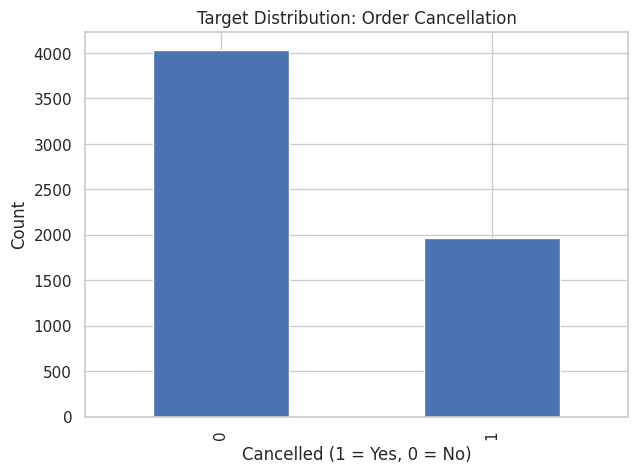

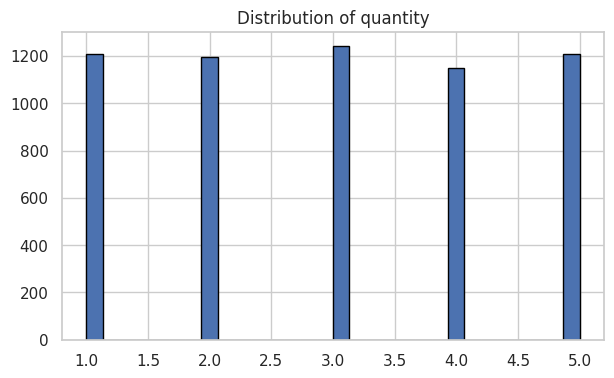

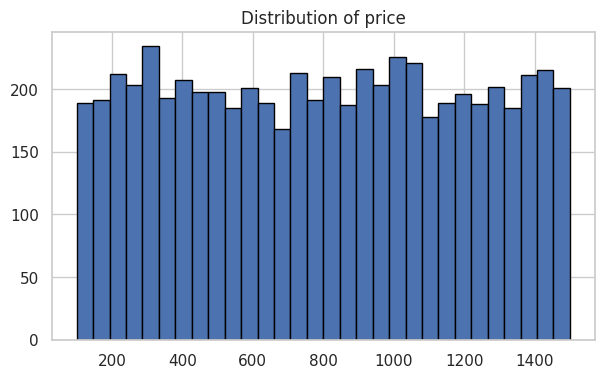

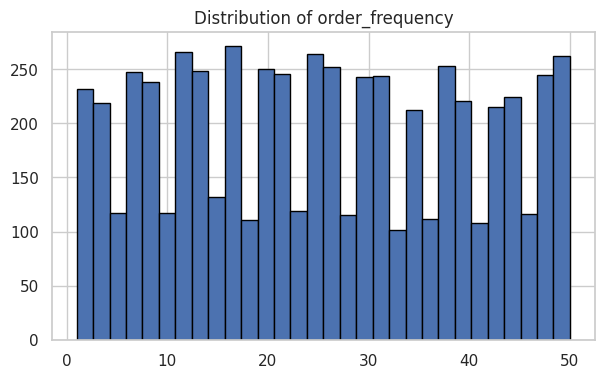

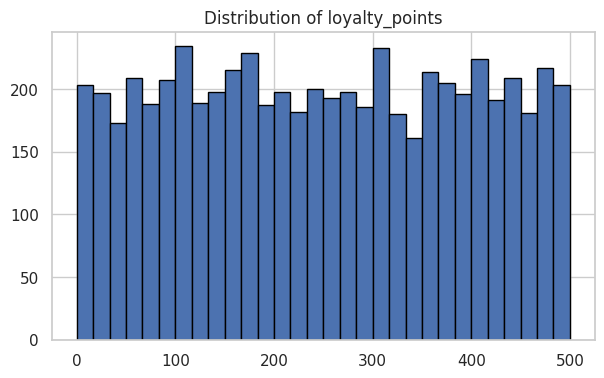

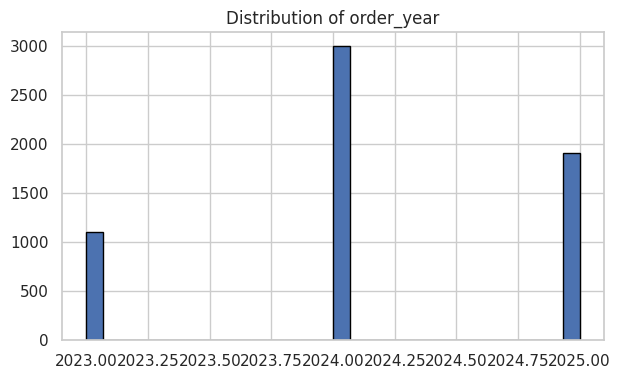

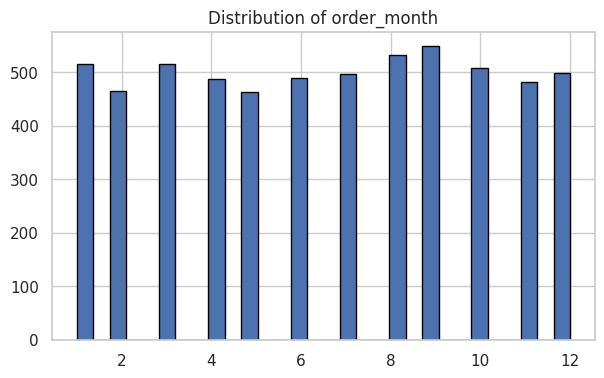

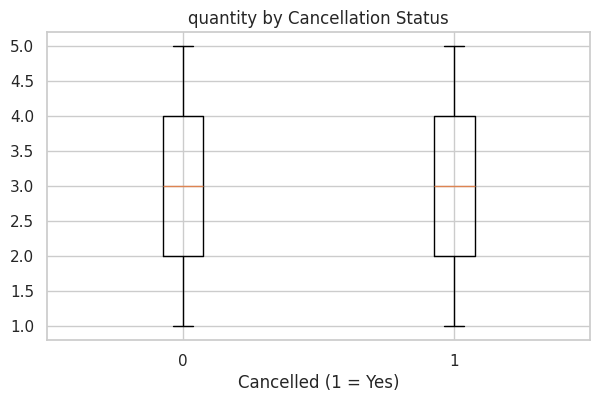

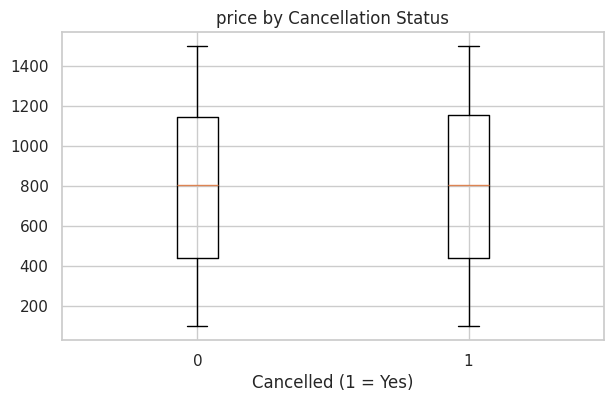

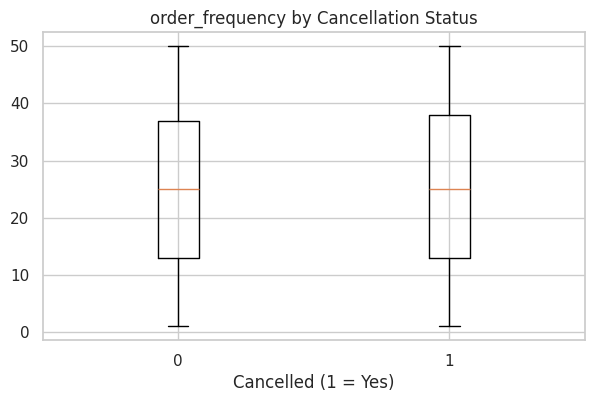

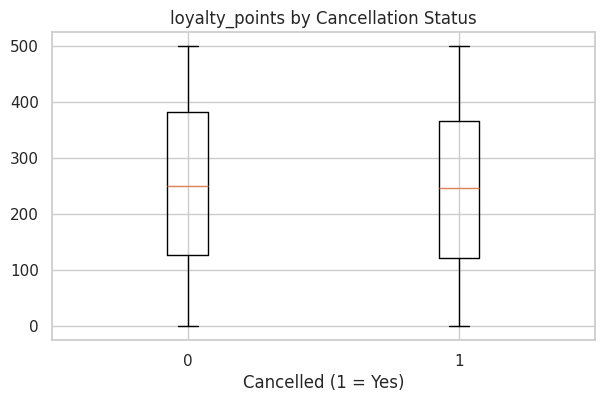

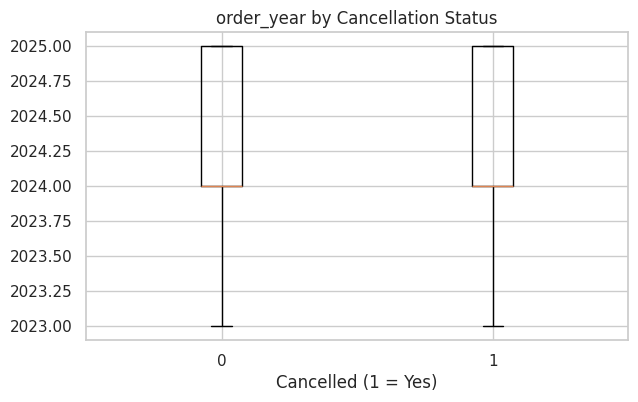

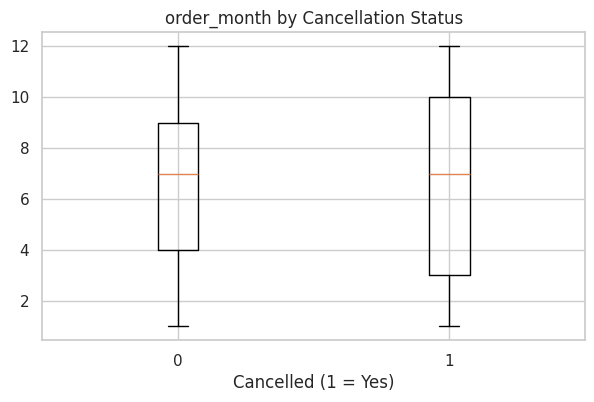

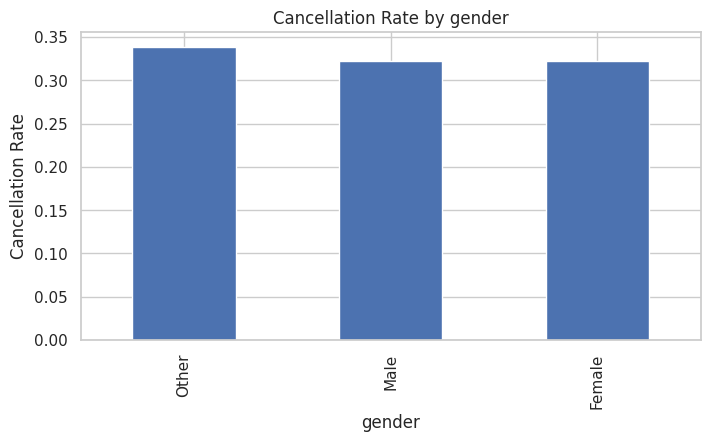

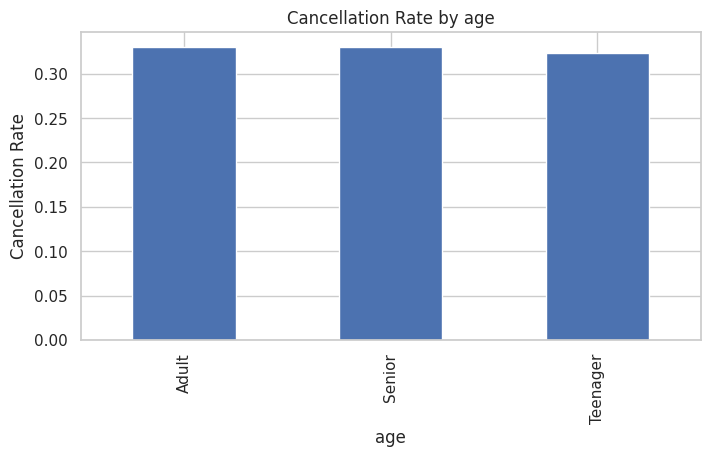

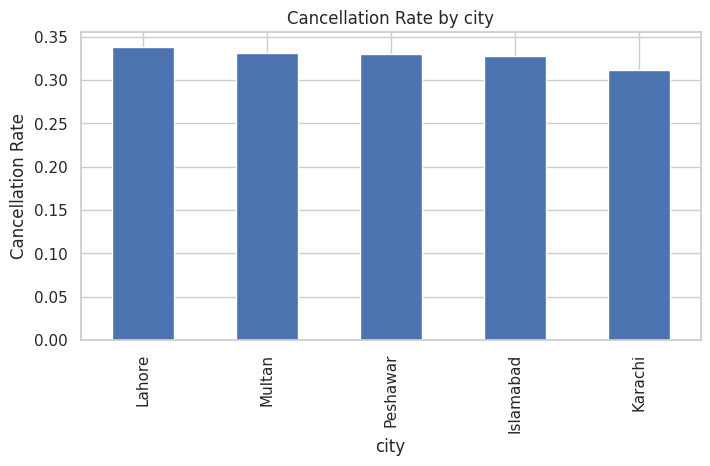

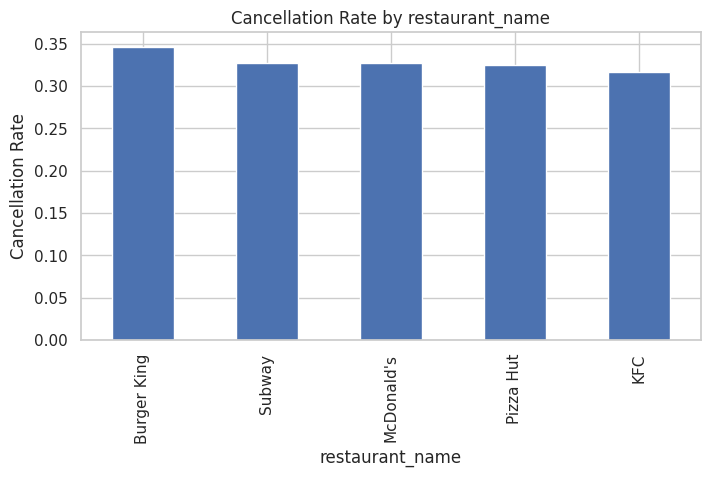

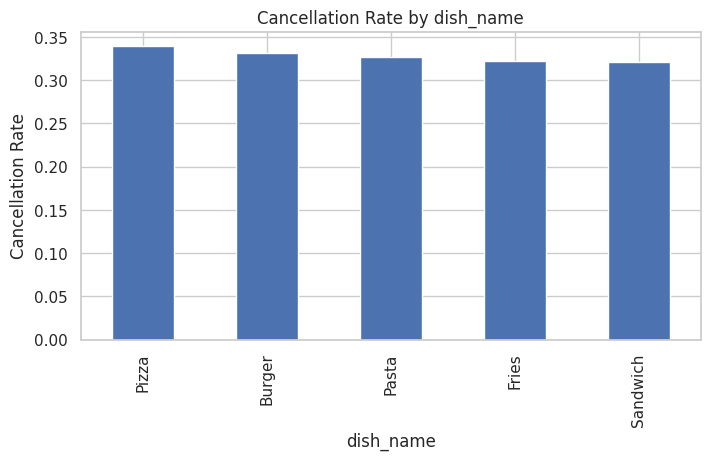

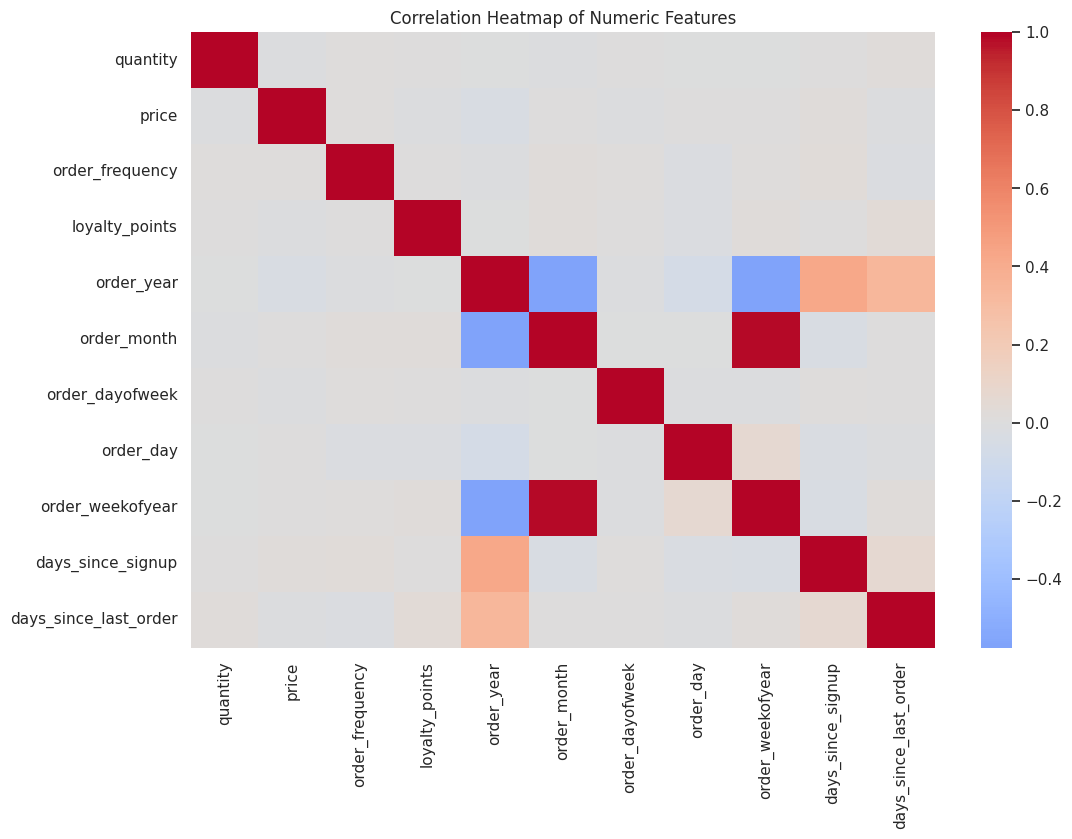

In [ ]:
# STEP 3: EDA and feature engineering visualizations
#
print('STEP 3: EDA AND FEATURE ENGINEERING')

eda_df = df_clean.copy()

# Plot 1: target distribution
plt.figure(figsize=(7, 5))
eda_df['target_cancelled'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution: Order Cancellation')
plt.xlabel('Cancelled (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# Plot 2: numerical distributions
for col in numeric_features[:6]:
    plt.figure(figsize=(7, 4))
    plt.hist(X[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.show()

# Plot 3: boxplots by target for important numerics
for col in numeric_features[:6]:
    plt.figure(figsize=(7, 4))
    box_data = [X.loc[y==0, col].dropna(), X.loc[y==1, col].dropna()]
    plt.boxplot(box_data, tick_labels=['0','1'])
    plt.title(f'{col} by Cancellation Status')
    plt.xlabel('Cancelled (1 = Yes)')
    plt.show()

# Plot 4: categorical cancellation rate
for col in categorical_features[:5]:
    tmp = pd.crosstab(X[col], y, normalize='index')
    if 1 in tmp.columns:
        plt.figure(figsize=(8, 4))
        tmp[1].sort_values(ascending=False).plot(kind='bar')
        plt.title(f'Cancellation Rate by {col}')
        plt.ylabel('Cancellation Rate')
        plt.show()

# Plot 5: correlation heatmap for numeric engineered variables
corr_cols = [c for c in numeric_features if c in X.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(12, 8))
    sns.heatmap(X[corr_cols].corr(), cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()


**STEP 4: MODEL IMPLEMENTATION**

SUPERVISED CLASSIFICATION MODELS

For this example, we will use Random Forest, XGBoost and SVM to know which model will provide the highest prediction of cancelled orders.

EDA and Feature Selection are also included here.

STEP 4: MODEL TRAINING FOR SUPERVISED CLASSIFICATION AND PREDICTION

Training Random Forest...
Correct predictions for Random Forest: 2014 out of 3000
              precision    recall  f1-score   support

           0     0.6719    0.9985    0.8033      2016
           1     0.2500    0.0010    0.0020       984

    accuracy                         0.6713      3000
   macro avg     0.4609    0.4998    0.4026      3000
weighted avg     0.5335    0.6713    0.5405      3000



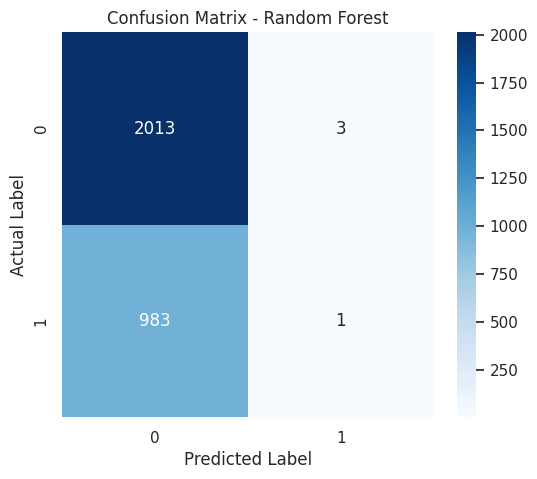


Training XGBoost...
Correct predictions for XGBoost: 1934 out of 3000
              precision    recall  f1-score   support

           0     0.6748    0.9097    0.7748      2016
           1     0.3546    0.1016    0.1580       984

    accuracy                         0.6447      3000
   macro avg     0.5147    0.5057    0.4664      3000
weighted avg     0.5698    0.6447    0.5725      3000



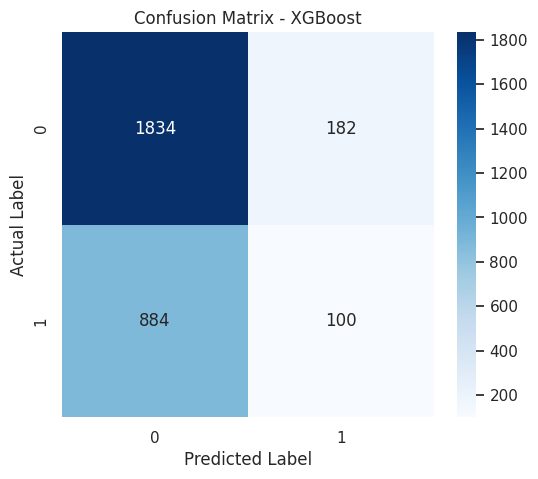


Training SVM...
Correct predictions for SVM: 1455 out of 3000
              precision    recall  f1-score   support

           0     0.6718    0.4568    0.5438      2016
           1     0.3278    0.5427    0.4087       984

    accuracy                         0.4850      3000
   macro avg     0.4998    0.4998    0.4763      3000
weighted avg     0.5590    0.4850    0.4995      3000



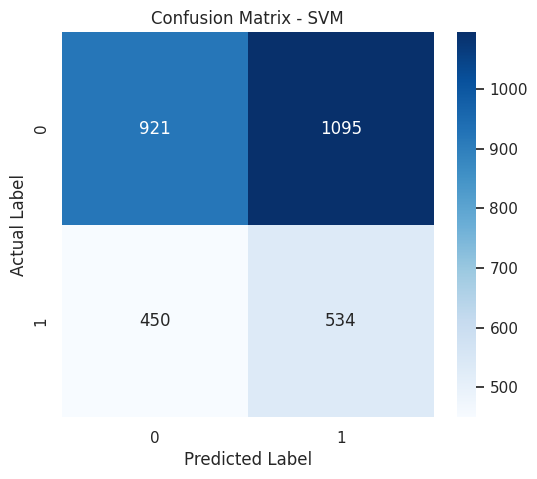


Model performance summary:


,model,accuracy,roc_auc,pr_auc,precision,recall,f1_score,correct_predictions,total_predictions
0,Random Forest,0.671333,0.520421,0.340028,0.250000,0.001016,0.002024,2014,3000
1,XGBoost,0.644667,0.508862,0.342794,0.354610,0.101626,0.157978,1934,3000
2,SVM,0.485000,0.501281,0.322063,0.327808,0.542683,0.408726,1455,3000



Top predicted cancellations:


,gender,age,city,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,...,order_year,order_month,order_dayofweek,order_day,order_weekofyear,days_since_signup,days_since_last_order,actual_cancelled,predicted_cancelled,predicted_cancel_probability
3663,Female,Teenager,Karachi,Subway,Fries,Dessert,5.0,383.11,Card,39.0,...,2024.0,11.0,4.0,8.0,45.0,78.0,NaN,0,0,0.391926
3887,Female,Teenager,Karachi,Burger King,Fries,Dessert,4.0,1394.75,Card,45.0,...,2024.0,12.0,4.0,6.0,49.0,107.0,NaN,0,0,0.390675
5384,Female,Teenager,Karachi,Subway,Fries,Italian,4.0,574.97,Cash,18.0,...,2025.0,6.0,4.0,6.0,23.0,141.0,209.0,0,0,0.388543
3420,Female,Teenager,Karachi,KFC,Fries,Italian,3.0,1223.56,Cash,32.0,...,2023.0,9.0,1.0,19.0,38.0,4.0,NaN,1,0,0.384096
500,Female,Teenager,Karachi,KFC,Burger,Italian,3.0,1452.68,Wallet,9.0,...,2024.0,7.0,3.0,25.0,30.0,NaN,NaN,1,0,0.382855
140,Male,Teenager,Karachi,Pizza Hut,Fries,Italian,5.0,122.84,Cash,43.0,...,2023.0,9.0,5.0,9.0,36.0,NaN,NaN,0,0,0.382287
3615,Other,Teenager,Karachi,Subway,Sandwich,Italian,3.0,1400.99,Card,12.0,...,2024.0,11.0,5.0,2.0,44.0,NaN,NaN,0,0,0.381024
5751,Female,Teenager,Karachi,Subway,Pizza,Italian,5.0,1467.70,Card,17.0,...,2024.0,10.0,1.0,22.0,43.0,NaN,49.0,1,0,0.380865
165,Female,Teenager,Karachi,KFC,Sandwich,Dessert,4.0,167.37,Cash,24.0,...,2023.0,9.0,0.0,11.0,37.0,NaN,NaN,0,0,0.380834
508,Female,Teenager,Karachi,KFC,Pasta,Italian,3.0,1173.19,Wallet,46.0,...,2023.0,10.0,5.0,21.0,42.0,NaN,NaN,0,0,0.380389


FEATURE IMPORTANCE AND EXPLAINABILITY

Top 20 feature importances - Random Forest


,feature,importance
0,price,0.093075
1,loyalty_points,0.088614
2,order_frequency,0.080219
3,order_day,0.074312
4,order_weekofyear,0.068146
5,days_since_signup,0.059737
6,order_dayofweek,0.047196
7,order_month,0.044911
8,quantity,0.038310
9,days_since_last_order,0.034088


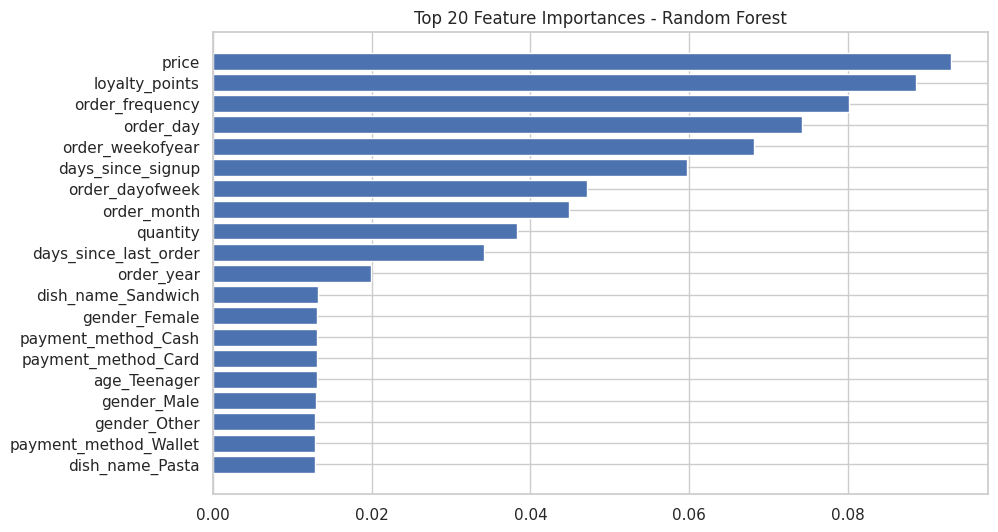


Top 20 feature importances - XGBoost


,feature,importance
0,city_Lahore,0.030489
1,gender_Female,0.030015
2,dish_name_Sandwich,0.028875
3,restaurant_name_McDonald's,0.028386
4,city_Peshawar,0.027729
5,restaurant_name_KFC,0.027089
6,dish_name_Fries,0.026992
7,dish_name_Pizza,0.026815
8,days_since_signup,0.025916
9,category_Chinese,0.025886


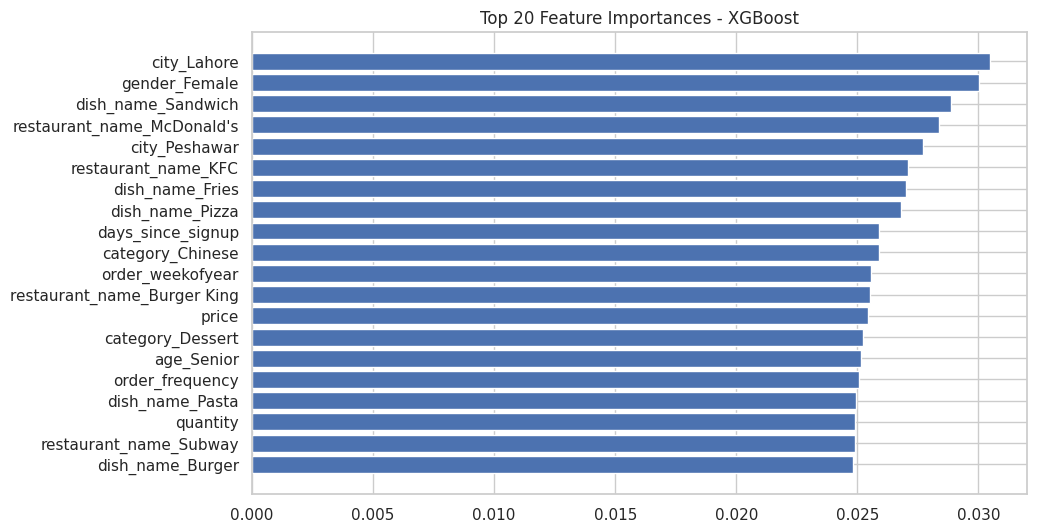


Top 20 feature importances - SVM


,feature,importance
0,city_Karachi,0.514801
1,category_Italian,0.371782
2,order_weekofyear,0.282661
3,category_Fast Food,0.269170
4,city_Multan,0.252810
5,category_Chinese,0.249435
6,age_Teenager,0.235590
7,gender_Female,0.217729
8,dish_name_Fries,0.217591
9,quantity,0.191199


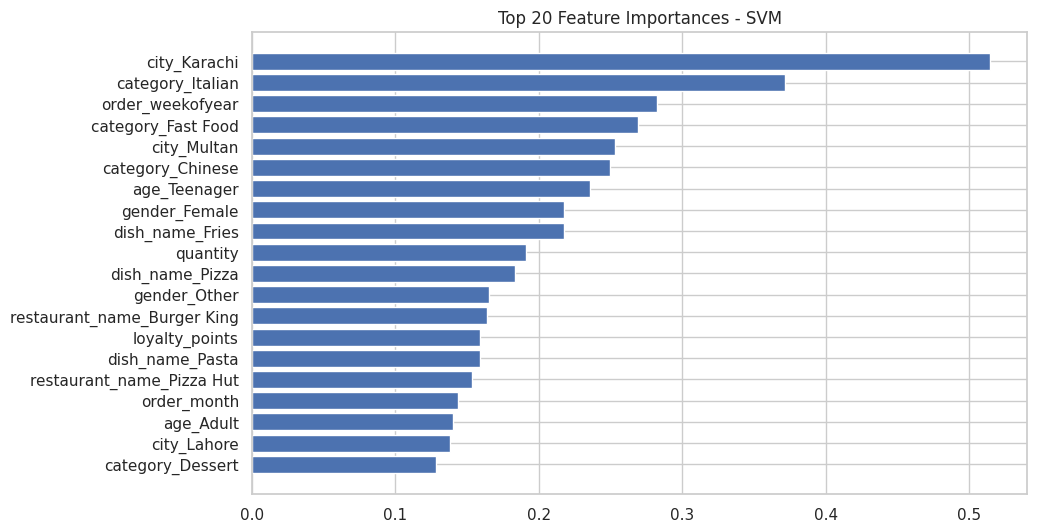


SHAP explanation for Random Forest...


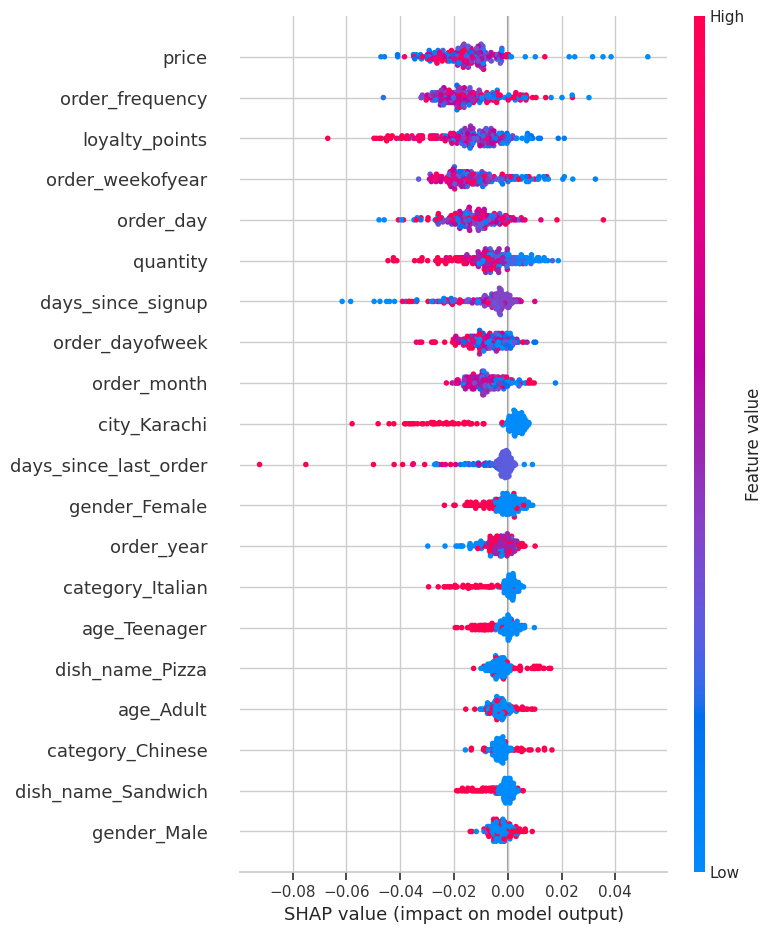

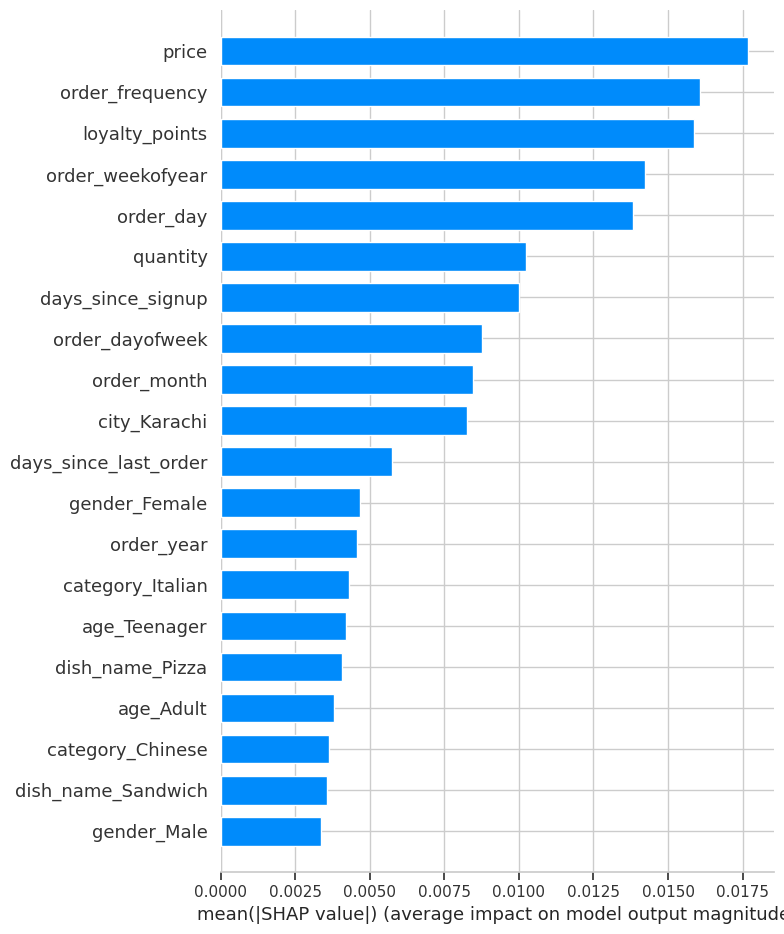


SHAP explanation for XGBoost...


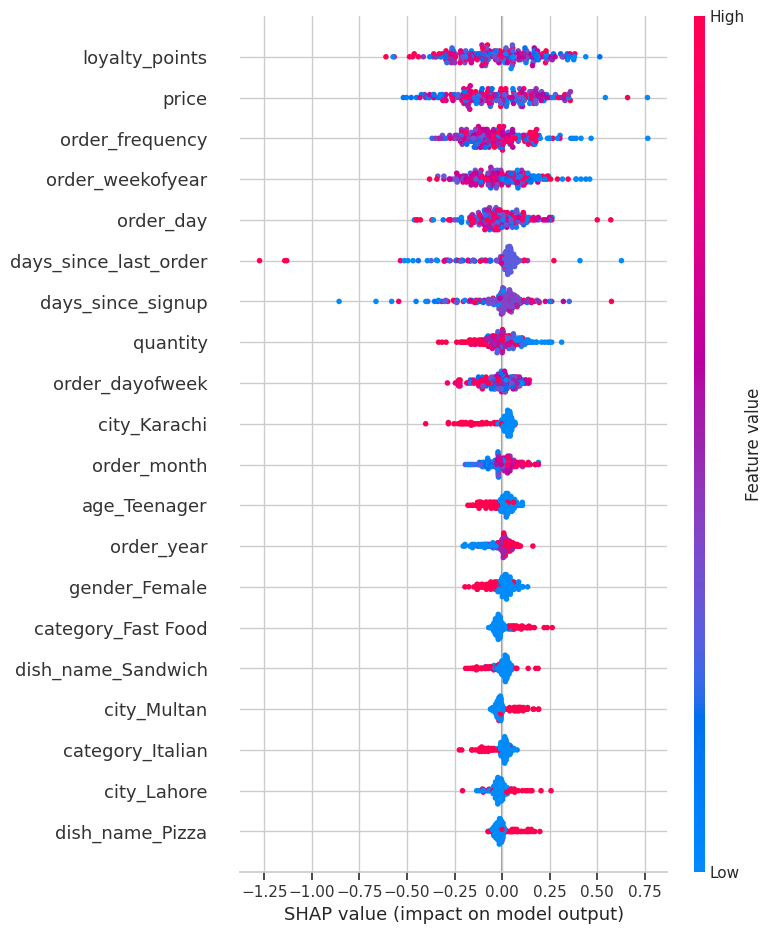

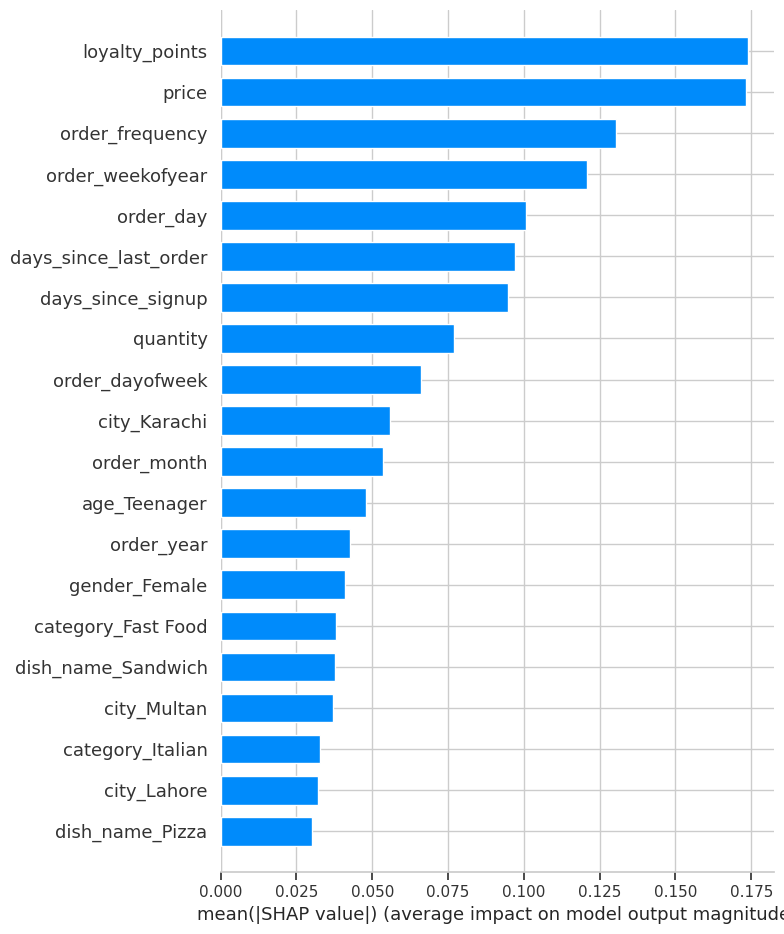


SHAP explanation for SVM...


  0%|          | 0/200 [00:00<?, ?it/s]

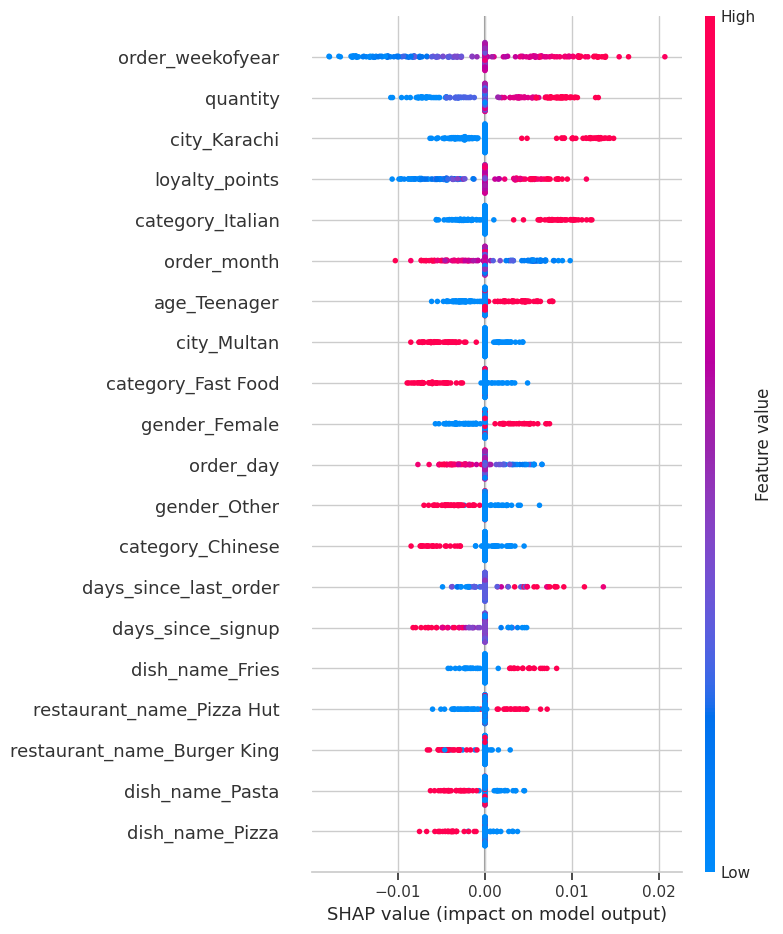

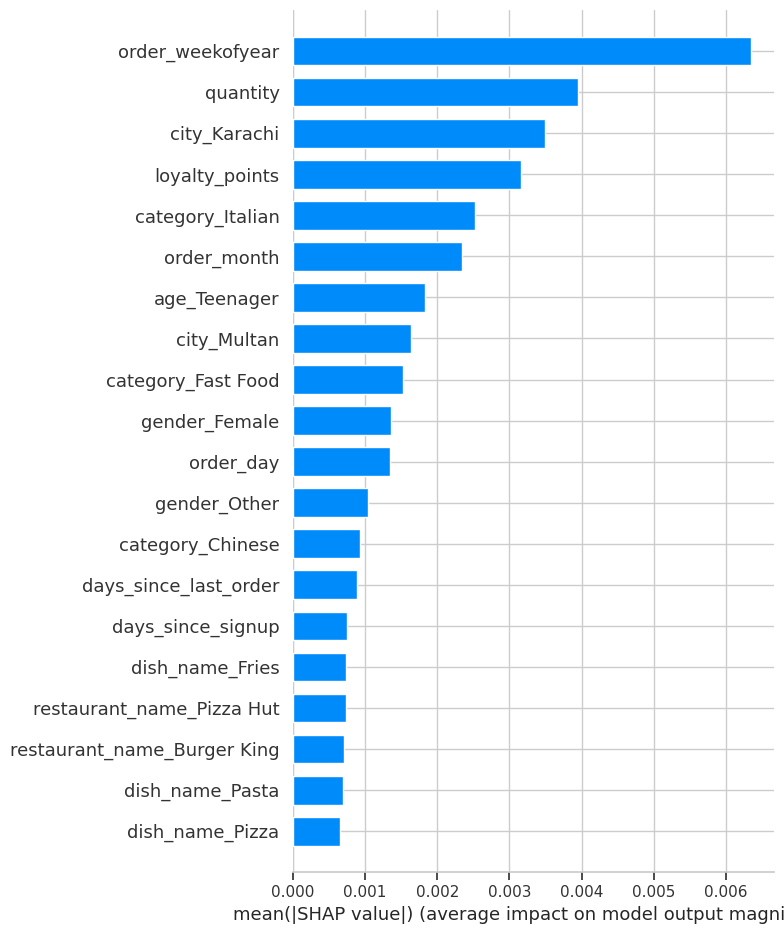

PDP/ICE will use the top features from the best model (SVM): ['city_Karachi', 'category_Italian', 'order_weekofyear']
PDP/ICE could not be generated for city_Karachi: cannot reshape array of size 1 into shape (2)
PDP/ICE could not be generated for category_Italian: cannot reshape array of size 1 into shape (2)


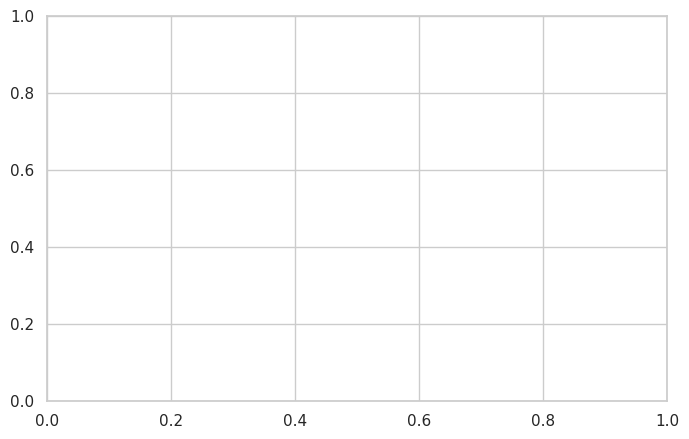

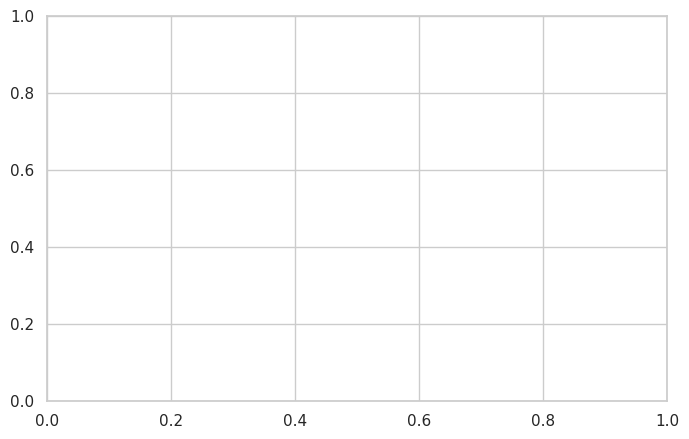

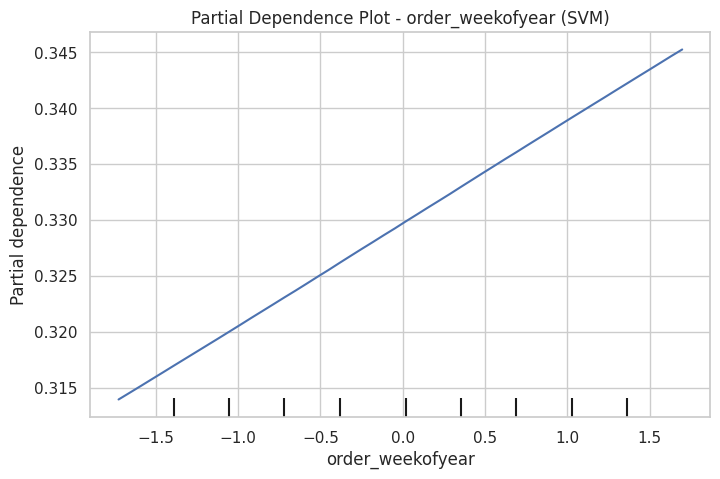

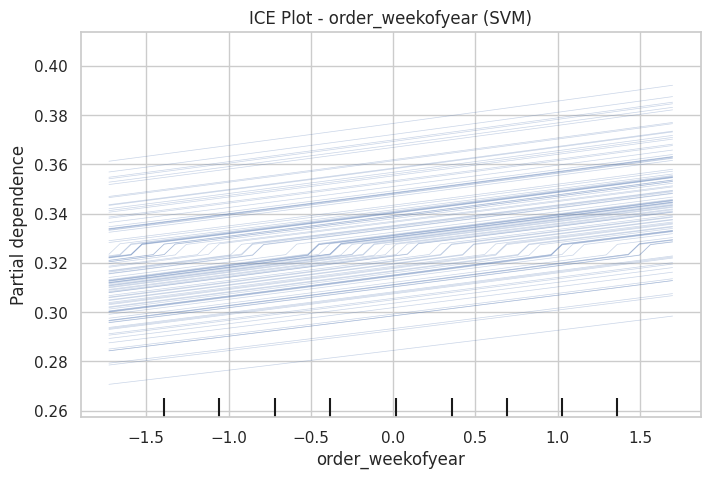

FEATURE SELECTION
Selected top 20 features using filter method (Mutual Information):


,selected_feature,mutual_information_score
0,age_Senior,0.017013
1,order_month,0.016512
2,payment_method_Card,0.015496
3,category_Italian,0.009023
4,city_Multan,0.008574
5,restaurant_name_KFC,0.008096
6,order_year,0.007881
7,city_Peshawar,0.007773
8,restaurant_name_McDonald's,0.006742
9,age_Adult,0.005907


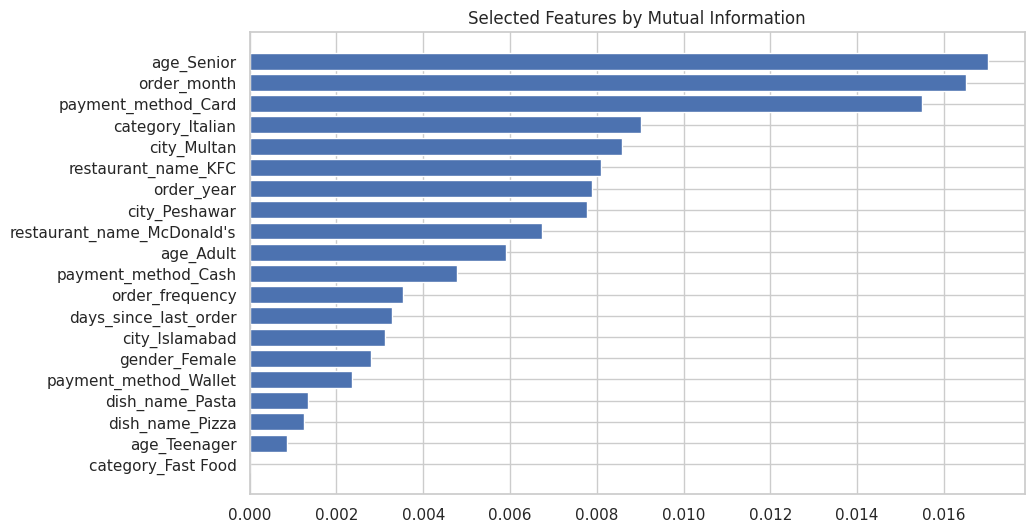

MODEL COMPARISON, ROC-AUC, PR-AUC, RECALL, PRECISION, F1


,model,roc_auc,pr_auc,recall,precision,f1_score,accuracy,correct_predictions,total_predictions
0,Random Forest,0.520421,0.340028,0.001016,0.250000,0.002024,0.671333,2014,3000
1,XGBoost,0.508862,0.342794,0.101626,0.354610,0.157978,0.644667,1934,3000
2,SVM,0.501281,0.322063,0.542683,0.327808,0.408726,0.485000,1455,3000


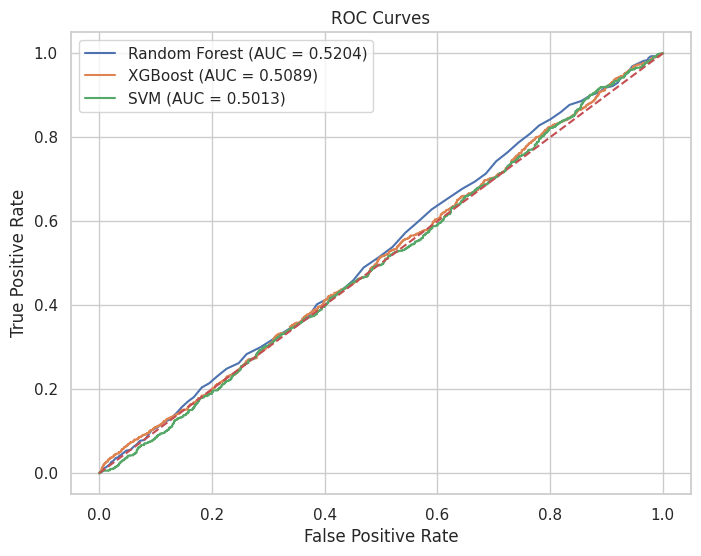

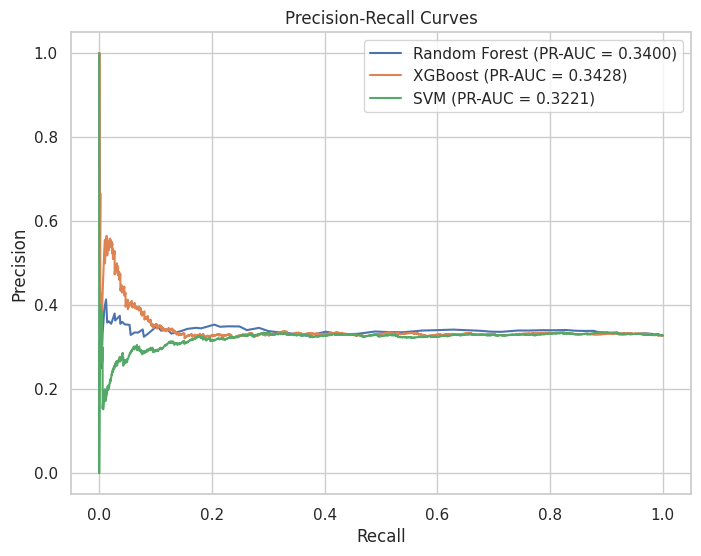

<Figure size 1200x600 with 0 Axes>

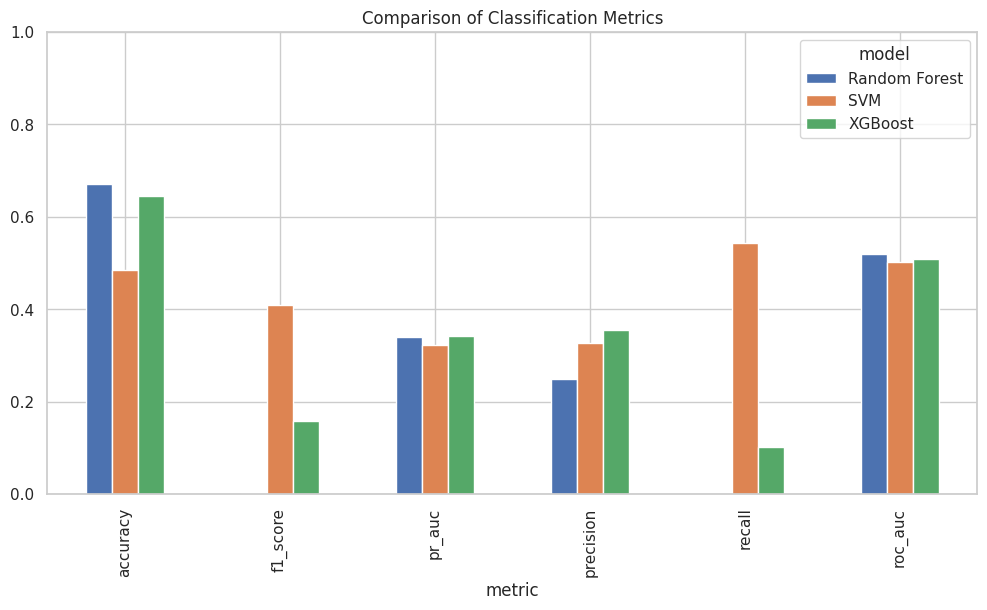

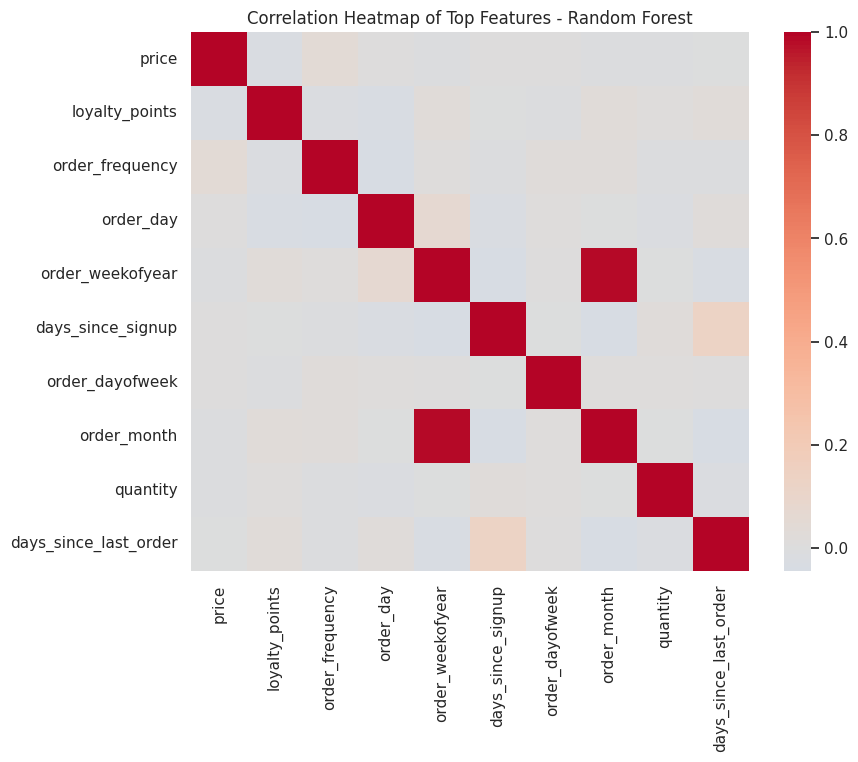

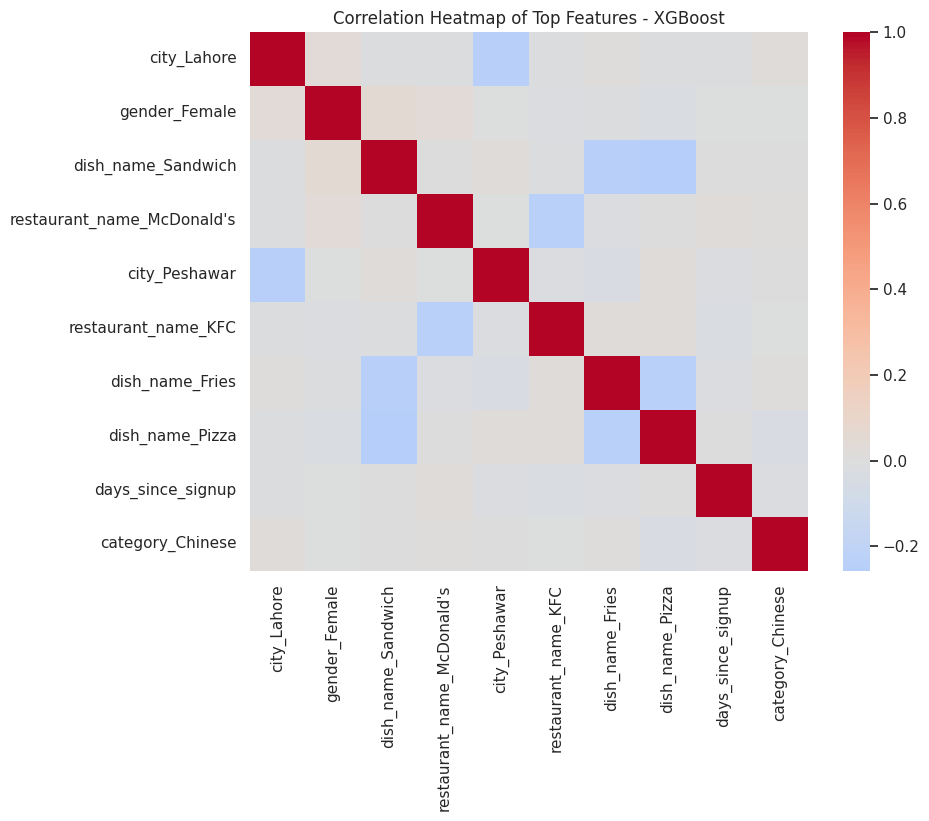

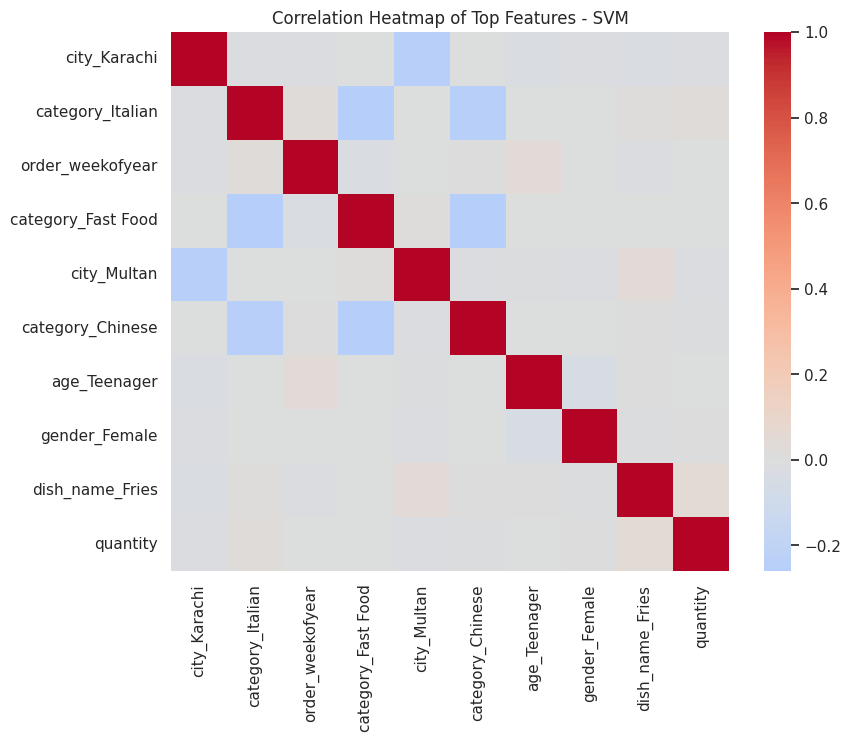


Detailed plots for Random Forest:


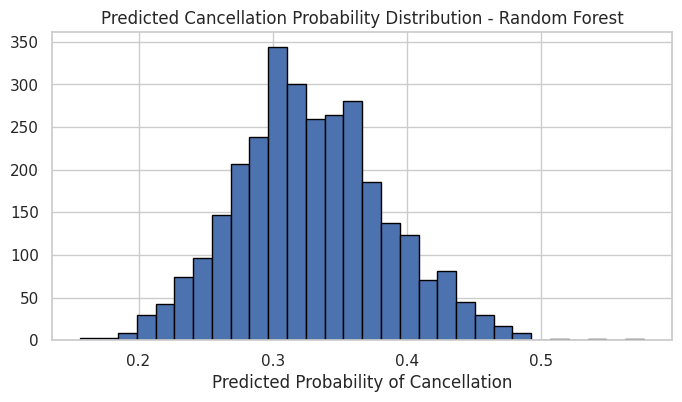


Detailed plots for XGBoost:


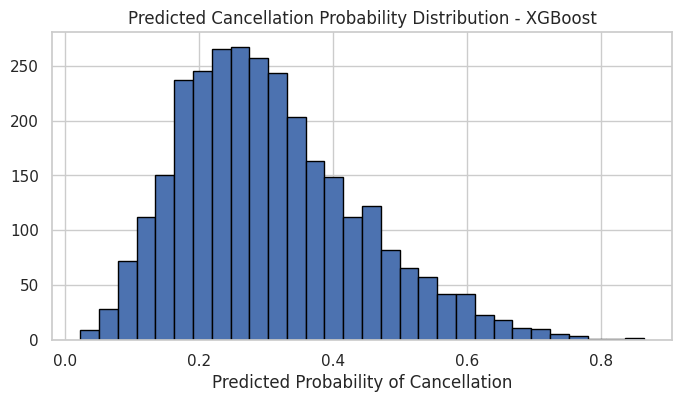


Detailed plots for SVM:


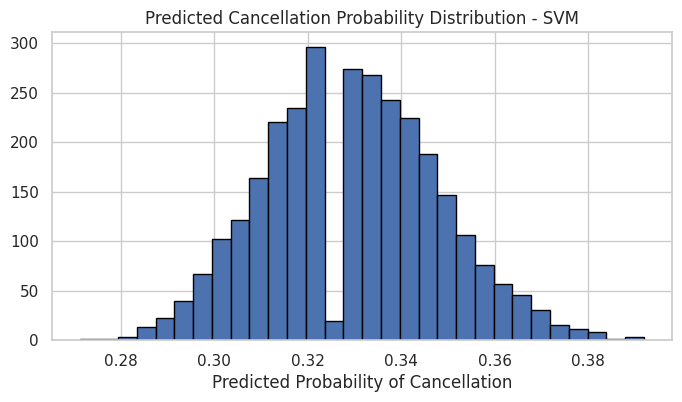


BEST MODEL: SVM
Reason: It has the highest recall and F1 score. It has the highest prediction of correct cancellations and has the lowest missed cancelled cases among all.

This is most evident in the confusion matrix.


In [ ]:
# STEP 4: Supervised classification with train/test split 50/50
# -----------------------------
print('STEP 4: MODEL TRAINING FOR SUPERVISED CLASSIFICATION AND PREDICTION')

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
        max_depth=None
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='linear',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

fitted_models = {}
results = []
prediction_store = {}

for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    model.fit(X_train_processed_df, y_train)
    fitted_models[model_name] = model

    y_pred = model.predict(X_test_processed_df)
    y_proba = model.predict_proba(X_test_processed_df)[:, 1]

    correct_predictions = int((y_pred == y_test).sum())
    total_predictions = len(y_test)

    metrics_row = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'correct_predictions': correct_predictions,
        'total_predictions': total_predictions
    }
    results.append(metrics_row)
    prediction_store[model_name] = {'pred': y_pred, 'proba': y_proba}

    print(f'Correct predictions for {model_name}: {correct_predictions} out of {total_predictions}')
    print(classification_report(y_test, y_pred, digits=4))
    plot_conf_matrix(y_test, y_pred, f'Confusion Matrix - {model_name}')

results_df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False).reset_index(drop=True)
print('\nModel performance summary:')
display(results_df)

best_model_name = results_df.iloc[2]['model']
# Replaced 0 to 2 because upon review of the confusion matrix, SVM is more capable of detecting more cancelled orders, despite lower F1 value compared to Random Forest
best_model = fitted_models[best_model_name]
# print(f"Best model based on ROC-AUC: {best_model_name}")

# Transaction-level predictions from best model
best_pred_labels = prediction_store[best_model_name]['pred']
best_pred_proba = prediction_store[best_model_name]['proba']
prediction_output = X_test.copy()
prediction_output['actual_cancelled'] = y_test.values
prediction_output['predicted_cancelled'] = best_pred_labels
prediction_output['predicted_cancel_probability'] = best_pred_proba
prediction_output = prediction_output.sort_values('predicted_cancel_probability', ascending=False)

print('\nTop predicted cancellations:')
display(prediction_output.head(20))


# Feature importance and explainability: SHAP, PDP, ICE
print('FEATURE IMPORTANCE AND EXPLAINABILITY')

# Generic feature importance function
feature_importance_tables = {}
for model_name, model in fitted_models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        perm = permutation_importance(model, X_test_processed_df, y_test, n_repeats=5, random_state=42, scoring='roc_auc')
        importances = perm.importances_mean

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    feature_importance_tables[model_name] = fi_df
    print(f'\nTop 20 feature importances - {model_name}')
    display(fi_df.head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(fi_df.head(20)['feature'][::-1], fi_df.head(20)['importance'][::-1])
    plt.title(f'Top 20 Feature Importances - {model_name}')
    plt.show()

# SHAP plots for each model using a manageable sample
background_size = min(100, len(X_train_processed_df))
explain_size = min(200, len(X_test_processed_df))
X_background = X_train_processed_df.sample(background_size, random_state=42)
X_explain = X_test_processed_df.sample(explain_size, random_state=42)

for model_name, model in fitted_models.items():
    print(f'\nSHAP explanation for {model_name}...')
    try:
        if model_name in ['Random Forest', 'XGBoost']:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_explain)
            if isinstance(shap_values, list):
                shap_values_plot = shap_values[1]
            elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
                shap_values_plot = shap_values[:, :, 1]
            else:
                shap_values_plot = shap_values
        else:
            # Kernel-based approach for SVM on a small sample for reliability
            predict_fn = lambda data: model.predict_proba(pd.DataFrame(data, columns=feature_names))[:, 1]
            explainer = shap.KernelExplainer(predict_fn, X_background)
            shap_values_plot = explainer.shap_values(X_explain, nsamples=100)

        shap.summary_plot(shap_values_plot, X_explain, feature_names=feature_names, show=True)
        shap.summary_plot(shap_values_plot, X_explain, feature_names=feature_names, plot_type='bar', show=True)
    except Exception as e:
        print(f'SHAP could not be completed for {model_name}: {e}')

# PDP and ICE for best model top features
best_fi_df = feature_importance_tables[best_model_name]
pdp_features = best_fi_df['feature'].head(min(3, len(best_fi_df))).tolist()
print(f'PDP/ICE will use the top features from the best model ({best_model_name}): {pdp_features}')

for feature in pdp_features:
    try:
        fig, ax = plt.subplots(figsize=(8, 5))
        PartialDependenceDisplay.from_estimator(
            best_model,
            X_test_processed_df,
            features=[feature],
            kind='average',
            ax=ax
        )
        plt.title(f'Partial Dependence Plot - {feature} ({best_model_name})')
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        PartialDependenceDisplay.from_estimator(
            best_model,
            X_test_processed_df,
            features=[feature],
            kind='individual',
            subsample=min(100, len(X_test_processed_df)),
            random_state=42,
            ax=ax
        )
        plt.title(f'ICE Plot - {feature} ({best_model_name})')
        plt.show()
    except Exception as e:
        print(f'PDP/ICE could not be generated for {feature}: {e}')


# Feature selection

print('FEATURE SELECTION')

# Filter method: Mutual Information
k_features = min(20, X_train_processed_df.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
selector.fit(X_train_processed_df, y_train)
selected_mask = selector.get_support()
selected_features = np.array(feature_names)[selected_mask]
selected_scores = selector.scores_[selected_mask]
feature_selection_df = pd.DataFrame({
    'selected_feature': selected_features,
    'mutual_information_score': selected_scores
}).sort_values(by='mutual_information_score', ascending=False).reset_index(drop=True)

print(f'Selected top {k_features} features using filter method (Mutual Information):')
display(feature_selection_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_selection_df.head(20)['selected_feature'][::-1], feature_selection_df.head(20)['mutual_information_score'][::-1])
plt.title('Selected Features by Mutual Information')
plt.show()


# Metrics and comparative visualization for RF, XGB, and SVM

print('MODEL COMPARISON, ROC-AUC, PR-AUC, RECALL, PRECISION, F1')

# Metric comparison table
metric_cols = ['roc_auc', 'pr_auc', 'recall', 'precision', 'f1_score', 'accuracy']
display(results_df[['model'] + metric_cols + ['correct_predictions', 'total_predictions']])

# ROC curves
plt.figure(figsize=(8, 6))
for model_name in models.keys():
    y_proba = prediction_store[model_name]['proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# PR curves
plt.figure(figsize=(8, 6))
for model_name in models.keys():
    y_proba = prediction_store[model_name]['proba']
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_score = average_precision_score(y_test, y_proba)
    plt.plot(recall_curve, precision_curve, label=f'{model_name} (PR-AUC = {pr_auc_score:.4f})')
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Bar chart of metrics
metrics_long = results_df.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')
plt.figure(figsize=(12, 6))
pivot_metrics = metrics_long.pivot(index='metric', columns='model', values='score')
pivot_metrics.plot(kind='bar', figsize=(12,6))
plt.title('Comparison of Classification Metrics')
plt.ylim(0, 1)
plt.show()

# Correlation heatmap for each model using its top 10 important features
for model_name, fi_df in feature_importance_tables.items():
    top_feats = fi_df['feature'].head(min(10, len(fi_df))).tolist()
    if len(top_feats) >= 2:
        plt.figure(figsize=(9, 7))
        sns.heatmap(X_train_processed_df[top_feats].corr(), cmap='coolwarm', center=0)
        plt.title(f'Correlation Heatmap of Top Features - {model_name}')
        plt.show()

# Model-specific plots (already printed confusion matrices and feature importances)
for model_name, model in fitted_models.items():
    print(f'\nDetailed plots for {model_name}:')
    # Decision score / probability distribution
    plt.figure(figsize=(8, 4))
    plt.hist(prediction_store[model_name]['proba'], bins=30, edgecolor='black')
    plt.title(f'Predicted Cancellation Probability Distribution - {model_name}')
    plt.xlabel('Predicted Probability of Cancellation')
    plt.show()

print(f'\nBEST MODEL: {best_model_name}')
print('Reason: It has the highest recall and F1 score. It has the highest prediction of correct cancellations and has the lowest missed cancelled cases among all.')
print(f'\nThis is most evident in the confusion matrix.')

**STEP 4: EVALUATION OF THE MODELS. COMPARISON OF RELEVAN METRICS.**

1. CONFUSION MATRIX, ROC-AUC, PR-AUC, RECALL, PRECISION AND F1 SCORE

In [ ]:
from google.colab import files
uploaded = files.upload()

# choose the file with filename "Confusion Matrix_RF-XGB-SVM.png" in the zip file attached.

Saving Confusion Matrix_RF-XGB-SVM.png to Confusion Matrix_RF-XGB-SVM.png


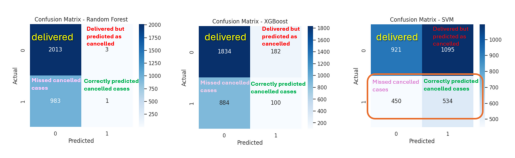

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open('Confusion Matrix_RF-XGB-SVM.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Looking at the confusion matrix, while the Random Forest is able to correctly predict high numbers of successfully delivered orders, it was only able to correctly predict one cancelled order, missing out the 983 actual cancelled orders. With this, even if Random Forest has the highest ROC-AUC and accuracy, it failed on our main goal of correctly detecting the cancelled orders. For the XGBoost model, while it has the highest PR-AUC and precision, this model was only able to correctly predict 100 cancelled orders missing out the other 884 cancelled orders. This missed opportunity is still high. Lastly, for the SVM, it achieved the highest recall and F1 score which is why it was able to correctly predict more than half of the cancelled orders correctly. This model would allow the management to correctly offer interventions to reduce order cancellations. However, it should also be noted that the SVM model also predicted a relatively high number of false positives (delivered but predicted as cancelled). This may result to additional cost to the management as they will be providing interventions (promos, vouchers, etc.) on orders that are likely to be successful but because they are “tagged” as potentially at risk, the cost on savings then may likely be reduced.

2. TOP 20 FEATURE IMPORTANCE - SVM
Looking at the Top 20 Feature Importance via SVM, we can see that the highest prevalence of cancelled orders is in the city of Karachi. There are a number of hypotheses that can be drawn from here:

    a. this area could be a heavy traffic area, and riders may have taken long before they get to deliver the food.

    b. this city might be far from the restaurants where customers usually order, and delivery time could be long most especially if customers will be ordering Italian food.

    c. alternatively, this city might have so many more restaurant/ fast food options nearby and so impatient customers would eventually cancel their orders and buy the food themselves instead.

From this information, the management can focus its interventions on this particular feature and the rest of the the top 5 features in order to optimize or maximize its use of its budget and avoid overspending on other features which are not highly predictive of order cancellation (example are customers located in cities that has low prevalence of order cancellations, etc.).

3. SHAP SUMMARY (BEESWARM) PLOT
This plot explains how each feature affects the model’s predictions. Looking at the SHAP summary (beeswarm) plot, it is already arranged based on importance. In the Y-axis, the order_weekofyear, quantity, and city_Karachi are the top 3 most influential features in the data that can predict cancellation of orders. The X-axis on the other hand is the impact on prediction. The right side (+) of the X-axis pushes prediction towards class 1 (Cancelled), and the left side (-) pushes the prediction towards the negative value which is class 0 (not cancelled). This means that the more positive it is, it increases the probability of cancellation. Since we have more red dots on the right (positive side), then these are the features that are more likely to be cancelled.

4. DISTRIBUTION DATA PLOT

In [ ]:
from google.colab import files
uploaded = files.upload()

# choose the file with filename "Distribution of price + order_month.png" in the zip file attached.

Saving Distribution of price + order_month.png to Distribution of price + order_month.png


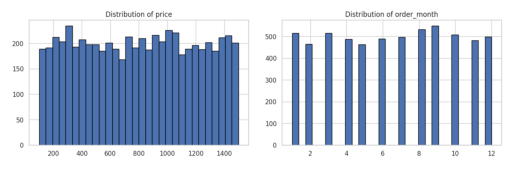

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open('Distribution of price + order_month.png')
plt.imshow(img)
plt.axis('off')
plt.show()

Looking at the Distribution of price and the number of cancelled orders, it can be seen that cancellation happens across the full range of the transactions’ price or amount. This means that the lost opportunities could range from a monetary value of 200 up to 1400.

On the otherhand, in the Distribution of order_month, it appears that high cancellations (>500 counts) occurred during the months of January, March, August, September and October. Given this information, the management may schedule a more assertive interventions (promos or vouchers) during the said months to reduce the number of cancelled orders.

**STEP 4: EVALUATION OF THE MODELS. COMPARISON OF RELEVANT METRICS**

1. CONFUSION MATRIX, ROC-AUC, PR-AUC, RECALL, PRECISION, & F1 SCORE

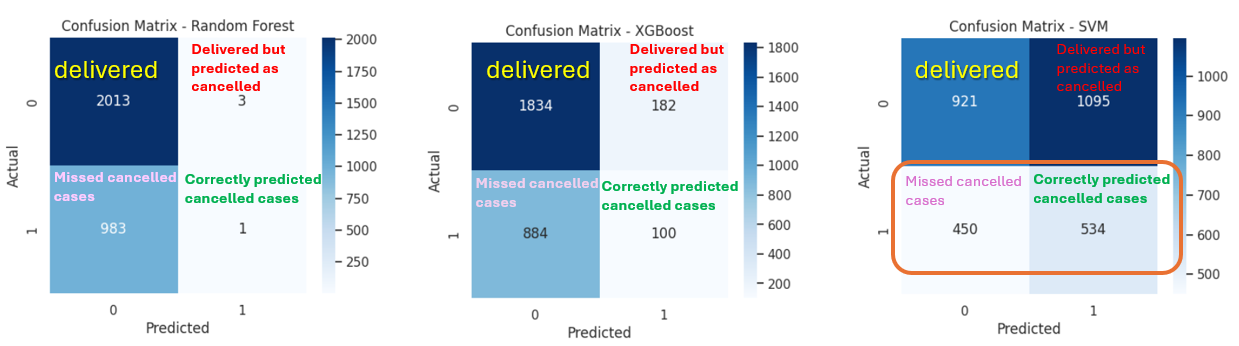

Looking at the confusion matrix, while the Random Forest is able to correctly predict high numbers of successfully delivered orders, it was only able to correctly predict one cancelled order, missing out the 983 actual cancelled orders. With this, even if Random Forest has the highest ROC-AUC and accuracy, it failed on our main goal of correctly detecting the cancelled orders.
For the XGBoost model, while it has the highest PR-AUC and precision, this model was only able to correctly predict 100 cancelled orders missing out the other 884 cancelled orders. This missed opportunity is still high.
Lastly, for the SVM, it achieved the highest recall and F1 score which is why it was able to correctly predict more than half of the cancelled orders correctly. This model would allow the management to correctly offer interventions to reduce order cancellations. However, it should also be noted that the SVM model also predicted a relatively high number of false positives (delivered but predicted as cancelled). This may result to additional cost to the management as they will be providing interventions (promos, vouchers, etc.) on orders that are likely to be successful but because they are “tagged” as potentially at risk, the cost on savings then may likely be reduced.

2. TOP 20 FEATURE IMPORTANCE - SVM

Looking at the Top 20 Feature Importance via SVM, we can see that the highest prevalence of cancelled orders is in the city of Karachi. There are a number of hypotheses that can be drawn from here:
  a. this area could be a heavy traffic area, and riders may have taken long before they get to deliver the food.

  b. this city might be far from the restaurants where customers usually order, and delivery time could be long most especially if customers will be ordering Italian food.

  c. alternatively, this city might have so many more restaurant/ fast food options nearby and so impatient customers would eventually cancel their orders and buy the food themselves instead.

From this information, the management can focus its interventions on this particular feature and the rest of the the top 5 features in order to optimize or maximize its use of its budget and avoid overspending on other features which are not highly predictive of order cancellation (example are customers located in cities that has low prevalence of order cancellations, etc.).

3. SHAP SUMMARY (BEESWARM) PLOT

This plot explains how each feature affects the model’s predictions. Looking at the SHAP summary (beeswarm) plot, it is already arranged based on importance. In the Y-axis, the order_weekofyear, quantity, and city_Karachi are the top 3 most influential features in the data that can predict cancellation of orders. The X-axis on the other hand is the impact on prediction. The right side (+) of the X-axis pushes prediction towards class 1 (Cancelled), and the left side (-) pushes the prediction towards the negative value which is class 0 (not cancelled). This means that the more positive it is, it increases the probability of cancellation. Since we have more red dots on the right (positive side), then these are the features that are more likely to be cancelled.


4. DISTRIBUTION DATA PLOT

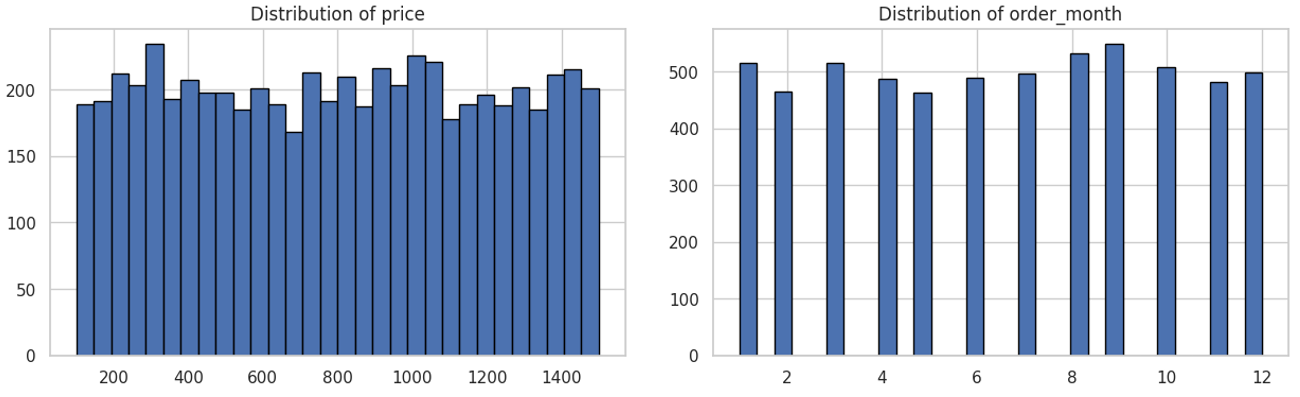

Looking at the Distribution of price and the number of cancelled orders, it can be seen that cancellation happens across the full range of the transactions’ price or amount. This means that the lost opportunities could range from a monetary value of 200 up to 1400.

On the otherhand, in the Distribution of order_month, it appears that high cancellations (>500 counts) occurred during the months of January, March, August, September and October. Given this information, the management may schedule a more assertive interventions (promos or vouchers) during the said months to reduce the number of cancelled orders.

**STEP 5: CRITICAL THINKING. ETHICAL AI AND BIAS AUDITING**


1.	Explain model decisions (SHAP, PDP, ICE).

    SHAP explains how much each feature contributed to the prediction. The farther it pushes the direction towards the right side (+), the more it predicts towards cancellation. While it is accurate and consistent, it assumes feature independence, which are not always true.
    PDP (Partial Dependence Plot) shows how, on the average, does changing one feature affect predictions. While this plot is easy to understand as it shows general trend, it also assumes features as independent variables, and if features are correlated, PDP may create unrealistic combinations. Also, since I have a number of categorical variables that were converted to numerical values, averaging them is not an ideal way of processing the data to make a meaningful interpretation.
    ICE (Individual Conditional Expectation) shows how one feature affects prediction for each individual order. Instead of the average, like in PDP, we can see many lines. While this plot shows heterogeneity or variations, it still assumes independence of features and may sometimes be hard to interpret especially if there are too many lines, which is also the case in this dataset.
    Given the observations mentioned, it is likely that the most reliable for this case is the SHAP model because it works at an individual and global level of explaining the features and does not rely on averaging. It is also able to answer the question: what are the top drivers of cancellation, which is related to the problem statement.


2. Address limitations (imbalance, leakage, overfitting).

    For the data leakage, these are the features “rating”, “rating_date”, and “churned”. Rating was dropped as it is given after the order is completed (or failed). If an order is cancelled, it may have no rating or have a very low rating. And this may give erroneous interpretation as the cancellation caused the rating, not the other way around. Rating date was also removed as this happens after fulfillment or cancellation. If rating_date exists then the order likely completed. If it is missing, then it is possibly cancelled. Churned is also dropped as it indicates whether the customer later stopped using the service. And since churn is influenced by cancellations, and not cause them, then this may make the model inaccurate.

    Given the type of problem statement that was defined here, the dataset can be said to have its limitations in the type of information it contains. The additional information needed to make the dataset more robust are the following variables as they are known to have some effect to the decision on whether the customer will cancel the order or not.

    a. app’s indicated delivery time

    b. time between the placement of order and the delivery (or cancellation)

    c. driver assignment time (how long for the order to be assigned to a driver)

    d. duration of time for the restaurant to fulfill the order

    e. reason for order cancellation (availability, waiting time, rush hour, etc.)

    f. types of cancellations (customer cancels due to change of mind, restaurant cancels due to out of stock, system cancels, or rider cancels)

    g. other external factors (weather, road works, holidays, etc.)

    It is very likely that due to the absence of these important information, or context, which is why the accuracy is low and the feature importance values are also low (0.5 and below), same with the SHAP values which are also low. If we want to increase the model’s predictive power, then we should have these information as well in the dataset.

    Another limitation of the dataset is the number of data. Here, the dataset is from August of 2024 up to August of 2025. In one of the distribution plots, it appears that there are months in a year when cancellation of orders are high, and there are those months in which cancellations are low. It would be best if the dataset in which the model will be trained will complete the whole one year to be able to capture more details and nuances that may be present in a one whole year-round (examples are certain holidays, festivities, or occurrences that happened in a particular month such as road repairs which resulted to heavy traffics which eventually resulted to customers cancelling orders due to longer waiting time, and so on).

3. Bias detection and fairness audits

    a. Check outputs across sensitive groups (gender, race, age, socioeconomic status).
    
    Looking at the distribution plots for each of the features, specifically “Cancellation Rate by gender”, there is a potential bias here as there is a gender category labelled as “Other”. Now, this “Other” may be one of these two possibilities: first is that the customers may identify themselves as part of the LGBTQ+ community, and this may potentially portray an image of “indecisiveness” on their part as they frequently cancel orders for whatever reason. The second is that this “Other” category may also be either of the male or female customers who do not want to divulge their gender for confidentiality purposes or sensitivity to the need to declare their gender. Either way, in terms of interpreting the data, the gender portion should be analyzed with much care as it may cause misleading insights.
    
    Another sensitive group is the distribution plot on “Cancellation Rate by age”. While the three classes (adult, senior, and teenager) were close in terms of cancellation rate, there should still be another class that can divide the “adult” category as it covers a wider range compared to the adult and teenager categories.


    b. Use fairness metrics (demographic parity, equalised odds, disparate impact).

    In the coding that can be seen below, for the demographic parity, it is said that a model satisfies demographic parity if the rate of predicted cancellations is equal across groups. When the code was executed, it showed that the difference between the highest prediction rate (Multan at 71.18%) and the lowest (Karachi at 17.08%) is approximately 54.10%. This indicates a significant disparity in predicted cancellation rates across different cities, which is an important finding for understanding potential biases or regional factors influencing order cancellations. This is normally addressed by adding more data points followed by an assessment as to whether the disparity can be justified by real data. This is to determine if there is bias or it is a real signal. Additionally, root cause analysis is also needed on why there is data imbalance. Here, it is important to know the context: are there logistics issues? Are there service quality issues? If the answer is yes, then this could be a good insight.
    When Equalized Odds was done for the City, this metric evaluates whether the model predicts positive outcomes (cancelled) and negative outcomes (not cancelled) equally well across different cities by comparing True Positive Rate (TPR) and False Positive Rate (FPR). Based on the result, there are noticeable differences in TPR and FPR across cities, with Multan and Peshawar having higher TPRs (better at identifying actual cancellations) but also higher FPRs (more false positives) compared to Karachi.
    
    When this Equalized Odds was done for the gender, there's a trend where the 'Other' group has the highest TPR and FPR, followed by 'Male' and then 'Female'. This suggests that the model's performance in terms of correctly identifying cancellations and incorrectly flagging non-cancellations varies by gender group. The 'Other' and 'Male' groups have higher rates of both correctly identified cancellations and false positives compared to the 'Female' group.



In [ ]:
import pandas as pd

# Demographic Parity

def demographic_parity(df, group_col, pred_col):
    result = df.groupby(group_col)[pred_col].mean()
    print('\n' + '='*80)
    print("Demographic Parity (Prediction Rate per Group):")
    print('='*80)
    print(result)
    print("\nDifference:", result.max() - result.min())

# Example usage:
# df['pred'] = model predictions (0/1)
demographic_parity(prediction_output, group_col='city', pred_col='predicted_cancelled')

# Equalized Odds
from sklearn.metrics import confusion_matrix

def equalized_odds(df, group_col, y_true, y_pred):
    groups = df[group_col].unique()

    for g in groups:
        subset = df[df[group_col] == g]
        tn, fp, fn, tp = confusion_matrix(subset[y_true], subset[y_pred]).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        print(f"Group: {g}")
        print(f"  TPR: {tpr:.3f}")
        print(f"  FPR: {fpr:.3f}")
        print()

print('\n' + '='*80)
print('EQUALIZED ODDS FOR CITY')
print('='*80)
equalized_odds(prediction_output, group_col='city', y_true='actual_cancelled', y_pred='predicted_cancelled')

print('\n' + '='*80)
print('EQUALIZED ODDS FOR GENDER')
print('='*80)
equalized_odds(prediction_output, group_col='gender', y_true='actual_cancelled', y_pred='predicted_cancelled')


Demographic Parity (Prediction Rate per Group):
city
Islamabad    0.541528
Karachi      0.170819
Lahore       0.609047
Multan       0.711811
Peshawar     0.649485
Name: predicted_cancelled, dtype: float64

Difference: 0.540992518283969

EQUALIZED ODDS FOR CITY
Group: Karachi
  TPR: 0.166
  FPR: 0.173

Group: Islamabad
  TPR: 0.536
  FPR: 0.544

Group: Lahore
  TPR: 0.565
  FPR: 0.632

Group: Multan
  TPR: 0.731
  FPR: 0.703

Group: Peshawar
  TPR: 0.696
  FPR: 0.627


EQUALIZED ODDS FOR GENDER
Group: Female
  TPR: 0.406
  FPR: 0.390

Group: Male
  TPR: 0.575
  FPR: 0.591

Group: Other
  TPR: 0.642
  FPR: 0.644



3. Bias detection & fairness audits:

    c.	Propose mitigations (reweighting, thresholds, augmentation, post-processing).

    Before we execute the mitigations, we identify which one of them is the most appropriate. Reweighing gives more importance to underrepresented or disadvantaged groups during training. It is good when class imbalance exists, some groups are underrepresented, and we want fairness built into the model. The downside of this is that it may reduce overall accuracy, and it can overweight noisy samples. For the threshold adjustment, instead of one global threshold (0.5), use different thresholds per group. This is most applicable if we want to fix equalized odds and model probabilities are reliable. The downside of this is that different rules per group may raise fairness/legal concerns, and it is harder to deploy operationally. For the data augmentation, the idea is to balance the dataset by increasing representation of minority class (cancelled) and underrepresented groups. This is mostly used when there is severe imbalance and we have a small dataset.

    For this dataset, it appears that the most suitable to use is the reweighting. This reweighting will be done on the “city” and “gender”. From the results below, the weights are calculated as the inverse of the proportion of the group and the proportion of the target within that group. For example, a higher weight means that particular instance belongs to a group that is underrepresented or a target class that is underrepresented within its group and thus needs to be emphasized more during model training to balance the representation.

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported for pd.Series

def compute_sample_weights(df_for_weights, group_col, target_col):
    group_counts = df_for_weights[group_col].value_counts(normalize=True)
    target_counts = df_for_weights[target_col].value_counts(normalize=True)

    weights = []

    for idx in df_for_weights.index:
        g = df_for_weights.loc[idx, group_col]
        y = df_for_weights.loc[idx, target_col]

        # Inverse of (proportion of group * proportion of target in that group)
        weight = 1 / (group_counts[g] * target_counts[y])
        weights.append(weight)

    return pd.Series(weights, index=df_for_weights.index)

# Calculate sample weights for 'city'
print('\n' + '='*80)
print('SAMPLE WEIGHTS FOR CITY (FIRST 5 ROWS)')
print('='*80)
sample_weights_city = compute_sample_weights(model_df, group_col='city', target_col='target_cancelled')
display(sample_weights_city.head())

# Calculate sample weights for 'gender'
print('\n' + '='*80)
print('SAMPLE WEIGHTS FOR GENDER (FIRST 5 ROWS)')
print('='*80)
sample_weights_gender = compute_sample_weights(model_df, group_col='gender', target_col='target_cancelled')
display(sample_weights_gender.head())

print('\n This means that City has more imbalance than gender as the weight range is from 7 to 15.')
print('\n High weights (like 15) mean that few samples exist and the model may overfit those cases and become sensitive to noise')
print('\n The good side is that the weights are not extreme (e.g., not 100+)')


SAMPLE WEIGHTS FOR CITY (FIRST 5 ROWS)


,0
0,15.030964
1,7.108735
2,7.108735
3,7.471608
4,15.410853



SAMPLE WEIGHTS FOR GENDER (FIRST 5 ROWS)


,0
0,9.069253
1,4.426659
2,4.543802
3,4.424466
4,9.309253



 This means that City has more imbalance than gender as the weight range is from 7 to 15.

 High weights (like 15) mean that few samples exist and the model may overfit those cases and become sensitive to noise

 The good side is that the weights are not extreme (e.g., not 100+)
